DATA_DIR: /content/drive/MyDrive/huggingface_datasets/phreshphish_extracted_features
USE_GPU: True
*train*features.parquet: 96 dosya, 498,255 satir
*test*features.parquet: 27 dosya, 168,060 satir
X_train: (498255, 30) X_test: (168060, 30)
Train phish orani: 44.46% | Test phish orani: 45.70%


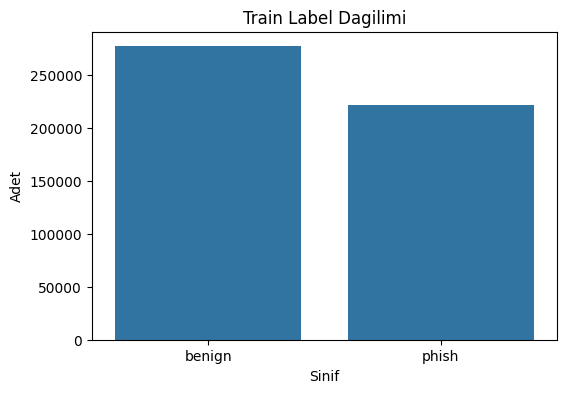

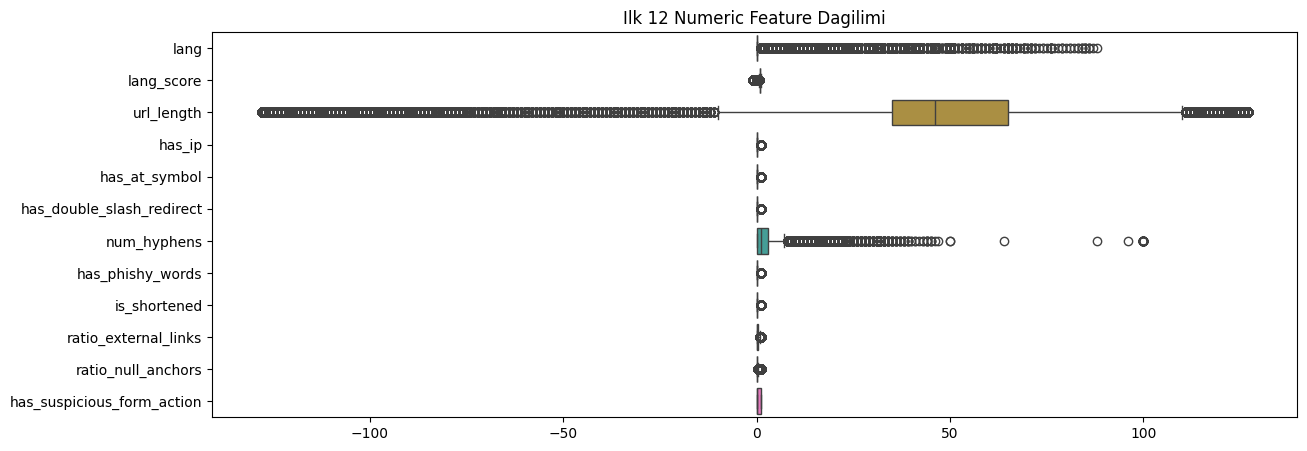

In [8]:
# =========================
# KISIM 1 - Veri Yukleme ve Gorsellestirme
# =========================

# Kurulum
import sys, subprocess
REQS = [
    "numpy", "pandas", "matplotlib", "seaborn",
    "scikit-learn", "xgboost", "lightgbm", "catboost", "optuna", "pyarrow"
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *REQS])

# Importlar
import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# GPU kontrol
try:
    import torch
    USE_GPU = torch.cuda.is_available()
except Exception:
    USE_GPU = False

# Drive mount (zaten bagliysa sorun degil)
try:
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive", force_remount=False)
except Exception:
    pass

# Yol bulma
DATA_CANDIDATES = [
    "/content/drive/MyDrive/huggingface_datasets/phreshphish_extracted_features",
    "/content/drive/MyDrive/Drive'im/huggingface_datasets/phreshphish_extracted_features",
    "/content/drive/MyDrive/Driveım/huggingface_datasets/phreshphish_extracted_features",
    "/content/drive/MyDrive/dataset/phreshphish_extracted_features",
]
DATA_DIR = next((p for p in DATA_CANDIDATES if os.path.exists(p)), None)
if DATA_DIR is None:
    raise FileNotFoundError("Dataset klasoru bulunamadi. DATA_CANDIDATES icine kendi yolunu ekle.")

print("DATA_DIR:", DATA_DIR)
print("USE_GPU:", USE_GPU)

def load_split(pattern):
    files = sorted(glob.glob(os.path.join(DATA_DIR, pattern)))
    if not files:
        raise FileNotFoundError(f"Dosya bulunamadi: {pattern}")
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    print(f"{pattern}: {len(files)} dosya, {df.shape[0]:,} satir")
    return df

df_train = load_split("*train*features.parquet")
df_test  = load_split("*test*features.parquet")

def pick_label(df):
    if "label_num" in df.columns:
        return pd.to_numeric(df["label_num"], errors="coerce").fillna(0).astype(int)
    if "label" in df.columns:
        return (df["label"].astype(str).str.lower().isin(["phish", "1", "true"])).astype(int)
    raise KeyError("label_num veya label kolonu yok.")

y_train = pick_label(df_train)
y_test = pick_label(df_test)

# Feature uretmeden mevcut kolonlar
drop_cols = ["label_num", "label", "url", "target", "sha256", "date", "html"]
X_train_df = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns], errors="ignore").copy()
X_test_df  = df_test.drop(columns=[c for c in drop_cols if c in df_test.columns], errors="ignore").copy()

common_cols = [c for c in X_train_df.columns if c in X_test_df.columns]
X_train_df = X_train_df[common_cols].copy()
X_test_df = X_test_df[common_cols].copy()

if X_train_df.shape[1] == 0:
    raise ValueError("Feature kolonu kalmadi.")

# Bool/Object -> sayisal (feature olusturma yok, kodlama var)
for c in X_train_df.columns:
    if X_train_df[c].dtype == "bool":
        X_train_df[c] = X_train_df[c].astype(int)
    if X_test_df[c].dtype == "bool":
        X_test_df[c] = X_test_df[c].astype(int)

obj_cols = [c for c in X_train_df.columns if str(X_train_df[c].dtype) in ["object", "category"]]
for c in obj_cols:
    tr = X_train_df[c].astype(str).fillna("__NA__")
    te = X_test_df[c].astype(str).fillna("__NA__")
    both = pd.concat([tr, te], axis=0)
    codes, _ = pd.factorize(both)
    X_train_df[c] = codes[:len(tr)]
    X_test_df[c] = codes[len(tr):]

for c in X_train_df.columns:
    X_train_df[c] = pd.to_numeric(X_train_df[c], errors="coerce")
    X_test_df[c] = pd.to_numeric(X_test_df[c], errors="coerce")

# Impute + Scale
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train_df)
X_test_imp = imputer.transform(X_test_df)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_imp)
X_test = scaler.transform(X_test_imp)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print(f"Train phish orani: {y_train.mean():.2%} | Test phish orani: {y_test.mean():.2%}")

# Gorsellestirme 1: Sinif dagilimi
plt.figure(figsize=(6,4))
sns.countplot(x=y_train.map({0:"benign", 1:"phish"}))
plt.title("Train Label Dagilimi")
plt.xlabel("Sinif")
plt.ylabel("Adet")
plt.show()

# Gorsellestirme 2: Ilk 12 numeric feature boxplot
tmp = X_train_df.select_dtypes(include=[np.number]).copy()
show_cols = tmp.columns[:12]
if len(show_cols) > 0:
    plt.figure(figsize=(14,5))
    sns.boxplot(data=tmp[show_cols], orient="h")
    plt.title("Ilk 12 Numeric Feature Dagilimi")
    plt.show()

In [9]:
# =========================
# KISIM 2 - Model Egitme ve Optimizasyon
# =========================

import time
import optuna
from optuna.samplers import TPESampler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

results = {}

def evaluate(name, model):
    print("\n" + "="*60)
    print(name, "egitiliyor...")
    t0 = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    print(f"Sure: {time.time()-t0:.1f}s | AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["benign","phish"]))
    results[name] = {"auc": auc, "model": model, "y_pred": y_pred, "y_proba": y_proba}

# Base modeller
evaluate("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42, n_jobs=1))
evaluate("Random Forest", RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=2))

# XGBoost default
xgb_device = "cuda" if USE_GPU else "cpu"
xgb_base = dict(
    n_estimators=260, learning_rate=0.07, max_depth=7, subsample=0.85, colsample_bytree=0.85,
    random_state=42, n_jobs=2, eval_metric="logloss", verbosity=0
)
try:
    evaluate("XGBoost (default)", XGBClassifier(**xgb_base, device=xgb_device))
except Exception as e:
    print("XGBoost GPU fallback CPU:", e)
    xgb_device = "cpu"
    evaluate("XGBoost (default)", XGBClassifier(**xgb_base, device="cpu"))

# XGBoost Optuna (hizli)
FAST_MODE = True
if FAST_MODE:
    sample_n = max(12000, int(len(y_train) * 0.12))
    n_trials = 6
    timeout_sec = 360
else:
    sample_n = max(25000, int(len(y_train) * 0.25))
    n_trials = 15
    timeout_sec = 1200

sample_n = min(sample_n, len(y_train))
rng = np.random.RandomState(42)
idx = rng.choice(len(y_train), size=sample_n, replace=False)

X_tune = X_train[idx]
y_tune = np.asarray(y_train)[idx]
X_tr, X_va, y_tr, y_va = train_test_split(X_tune, y_tune, test_size=0.2, random_state=42, stratify=y_tune)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 420),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.25, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
        "gamma": trial.suggest_float("gamma", 0.0, 3.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.0),
        "eval_metric": "logloss",
        "verbosity": 0,
        "random_state": 42,
        "n_jobs": 2,
    }
    try:
        m = XGBClassifier(**params, device=xgb_device)
        m.fit(X_tr, y_tr)
        return roc_auc_score(y_va, m.predict_proba(X_va)[:, 1])
    except Exception:
        m = XGBClassifier(**params, device="cpu")
        m.fit(X_tr, y_tr)
        return roc_auc_score(y_va, m.predict_proba(X_va)[:, 1])

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=n_trials, timeout=timeout_sec, show_progress_bar=False)

best_params = study.best_params
best_params.update({
    "device": xgb_device, "eval_metric": "logloss", "verbosity": 0, "random_state": 42, "n_jobs": 2
})

try:
    xgb_tuned = XGBClassifier(**best_params)
    xgb_tuned.fit(X_train, y_train)
except Exception:
    best_params["device"] = "cpu"
    xgb_device = "cpu"
    xgb_tuned = XGBClassifier(**best_params)
    xgb_tuned.fit(X_train, y_train)

y_pred_tuned = xgb_tuned.predict(X_test)
y_proba_tuned = xgb_tuned.predict_proba(X_test)[:, 1]
auc_tuned = roc_auc_score(y_test, y_proba_tuned)
print(f"\nXGBoost (tuned) AUC: {auc_tuned:.4f}")

# LGBM + CatBoost (CatBoost'u stabilite icin CPU)
lgbm_params = dict(
    n_estimators=350, max_depth=10, learning_rate=0.06, subsample=0.8, colsample_bytree=0.95,
    random_state=42, verbose=-1
)
if USE_GPU:
    lgbm_params["device"] = "gpu"

cat_params = dict(
    iterations=350, depth=8, learning_rate=0.06, bootstrap_type="Bernoulli",
    subsample=0.8, random_state=42, verbose=0, task_type="CPU", thread_count=2
)

evaluate("LightGBM", LGBMClassifier(**lgbm_params))
evaluate("CatBoost", CatBoostClassifier(**cat_params))

# all_results sozlugu
all_results = {
    "Logistic Regression": results["Logistic Regression"],
    "Random Forest": results["Random Forest"],
    "XGBoost (default)": results["XGBoost (default)"],
    "XGBoost (tuned)": {"auc": auc_tuned, "model": xgb_tuned, "y_pred": y_pred_tuned, "y_proba": y_proba_tuned},
    "LightGBM": results["LightGBM"],
    "CatBoost": results["CatBoost"],
}


Logistic Regression egitiliyor...
Sure: 3.6s | AUC: 0.9092
              precision    recall  f1-score   support

      benign       0.84      0.86      0.85     91260
       phish       0.83      0.81      0.82     76800

    accuracy                           0.84    168060
   macro avg       0.84      0.83      0.84    168060
weighted avg       0.84      0.84      0.84    168060


Random Forest egitiliyor...
Sure: 102.4s | AUC: 0.9841
              precision    recall  f1-score   support

      benign       0.90      0.98      0.94     91260
       phish       0.97      0.87      0.92     76800

    accuracy                           0.93    168060
   macro avg       0.94      0.92      0.93    168060
weighted avg       0.93      0.93      0.93    168060


XGBoost (default) egitiliyor...
Sure: 3.1s | AUC: 0.9852
              precision    recall  f1-score   support

      benign       0.92      0.97      0.95     91260
       phish       0.96      0.90      0.93     76800

    accu

=== KALİBRASYON KARŞıLAŞTIRMASI ===
  Ham XGBoost      Brier=0.0424  AUC=0.9871
  Isotonic         Brier=0.0448  AUC=0.9865
  Sigmoid          Brier=0.0477  AUC=0.9871


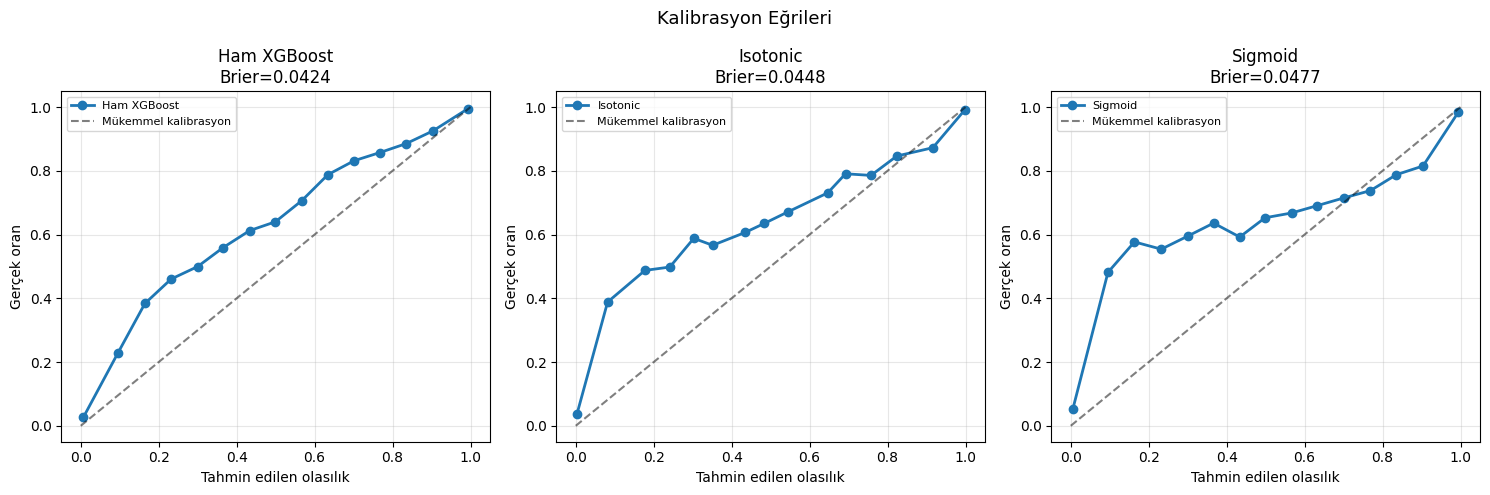


Seçilen kalibrasyon: Isotonic

   tau   PassRisk    BlkPrec   Recall  PR<=0.01  BP>=0.95
--------------------------------------------------------------
  0.05     0.0363     0.9213   0.9583  ✗         ✗
  0.10     0.0456     0.9384   0.9462  ✗         ✗
  0.15     0.0498     0.9454   0.9406  ✗         ✗
  0.20     0.0606     0.9584   0.9259  ✗         ✓
  0.25     0.0618     0.9600   0.9243  ✗         ✓
  0.30     0.0618     0.9600   0.9243  ✗         ✓
  0.35     0.0660     0.9640   0.9185  ✗         ✓
  0.40     0.0670     0.9650   0.9170  ✗         ✓
  0.45     0.0703     0.9679   0.9124  ✗         ✓
  0.50     0.0772     0.9734   0.9026  ✗         ✓
  0.55     0.0785     0.9742   0.9009  ✗         ✓
  0.60     0.0785     0.9742   0.9008  ✗         ✓
  0.65     0.0835     0.9772   0.8936  ✗         ✓
  0.70     0.0895     0.9798   0.8850  ✗         ✓
  0.75     0.0895     0.9798   0.8850  ✗         ✓
  0.80     0.0933     0.9813   0.8795  ✗         ✓
  0.85     0.1070     0.9853   

In [25]:
# =============================================================
# XGBOOST KALİBRASYONU
# Isotonic regression ile kalibrasyon (daha esnek)
# Platt scaling (sigmoid) ile karşılaştırma
# =============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, brier_score_loss

# Kalibrasyon için train'den ayrı bir val seti lazım
# (test'e dokunmuyoruz)
X_cal_tr, X_cal_val, y_cal_tr, y_cal_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

base_model = all_results["XGBoost (tuned)"]["model"]

# İki kalibrasyon yöntemi
cal_isotonic = CalibratedClassifierCV(base_model, method="isotonic", cv="prefit")
cal_sigmoid  = CalibratedClassifierCV(base_model, method="sigmoid",  cv="prefit")

cal_isotonic.fit(X_cal_val, y_cal_val)
cal_sigmoid.fit(X_cal_val,  y_cal_val)

# Test üzerinde olasılıklar
proba_raw      = np.array(all_results["XGBoost (tuned)"]["y_proba"])
proba_isotonic = cal_isotonic.predict_proba(X_test)[:, 1]
proba_sigmoid  = cal_sigmoid.predict_proba(X_test)[:,  1]
y_true         = np.array(y_test)

# Brier skoru (ne kadar düşükse kalibrasyon o kadar iyi)
print("=== KALİBRASYON KARŞıLAŞTIRMASI ===")
for isim, proba in [("Ham XGBoost", proba_raw),
                    ("Isotonic",    proba_isotonic),
                    ("Sigmoid",     proba_sigmoid)]:
    brier = brier_score_loss(y_true, proba)
    auc   = roc_auc_score(y_true, proba)
    print(f"  {isim:<15}  Brier={brier:.4f}  AUC={auc:.4f}")

# Kalibrasyon eğrisi (görsel)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (isim, proba) in zip(axes, [
    ("Ham XGBoost", proba_raw),
    ("Isotonic",    proba_isotonic),
    ("Sigmoid",     proba_sigmoid)
]):
    prob_true, prob_pred = calibration_curve(y_true, proba, n_bins=15, strategy="uniform")
    ax.plot(prob_pred, prob_true, marker="o", lw=2, label=isim)
    ax.plot([0,1],[0,1], "k--", alpha=0.5, label="Mükemmel kalibrasyon")
    ax.set_title(f"{isim}\nBrier={brier_score_loss(y_true,proba):.4f}")
    ax.set_xlabel("Tahmin edilen olasılık")
    ax.set_ylabel("Gerçek oran")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Kalibrasyon Eğrileri", fontsize=13)
plt.tight_layout()
plt.savefig("calibration_curves.png", dpi=300)
plt.show()

# En iyi kalibrasyonu seç
brier_iso = brier_score_loss(y_true, proba_isotonic)
brier_sig = brier_score_loss(y_true, proba_sigmoid)
best_cal_name  = "Isotonic" if brier_iso <= brier_sig else "Sigmoid"
best_cal_proba = proba_isotonic if brier_iso <= brier_sig else proba_sigmoid
best_cal_model = cal_isotonic if brier_iso <= brier_sig else cal_sigmoid

print(f"\nSeçilen kalibrasyon: {best_cal_name}")

# Kalibre edilmiş modelle pass risk tablosu
print(f"\n{'tau':>6} {'PassRisk':>10} {'BlkPrec':>10} {'Recall':>8}  PR<=0.01  BP>=0.95")
print("-"*62)
for t in np.linspace(0.05, 0.95, 19):
    pass_mask  = best_cal_proba < t
    blk_mask   = best_cal_proba >= t
    pass_risk  = float(y_true[pass_mask].mean()) if pass_mask.sum() > 0 else 0
    block_prec = float(y_true[blk_mask].mean())  if blk_mask.sum()  > 0 else 0
    rec        = recall_score(y_true, (best_cal_proba>=t).astype(int), zero_division=0)
    pr_ok = "✓" if pass_risk  <= 0.01 else "✗"
    bp_ok = "✓" if block_prec >= 0.95 else "✗"
    print(f"{t:>6.2f} {pass_risk:>10.4f} {block_prec:>10.4f} {rec:>8.4f}  {pr_ok}         {bp_ok}")

# all_results'u kalibre edilmiş versiyonla güncelle
all_results["XGBoost (calibrated)"] = {
    "model"  : best_cal_model,
    "y_proba": best_cal_proba,
    "y_pred" : (best_cal_proba >= 0.5).astype(int),
    "auc"    : roc_auc_score(y_true, best_cal_proba)
}
print(f"\nall_results['XGBoost (calibrated)'] eklendi.")

In [13]:
# 3 eşiği karşılaştır: 0.23 (optimal), 0.47 (eski), 0.50 (referans)
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

y_true = np.array(y_test)
n_test = len(y_true)

def report(tau):
    pred = (y_proba >= tau).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_true, pred).ravel()
    return dict(
        TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn),
        Precision=round(precision_score(y_true,pred,zero_division=0),4),
        Recall=round(recall_score(y_true,pred,zero_division=0),4),
        F1=round(f1_score(y_true,pred,zero_division=0),4)
    )

r050 = report(0.50)
r047 = report(0.47)
r023 = report(0.23)

print(f"{'Metrik':<12} {'tau=0.50':>10} {'tau=0.47':>10} {'tau=0.23':>10}")
print("-"*44)
for k in ["TP","TN","FP","FN","Precision","Recall","F1"]:
    print(f"  {k:<10} {str(r050[k]):>10} {str(r047[k]):>10} {str(r023[k]):>10}")

print(f"\n  0.50 → 0.23: FN azalması = {r050['FN']-r023['FN']:,}")
print(f"  0.50 → 0.23: FP artışı   = {(r023['FP']-r050['FP'])/n_test*100:.2f}%")
print(f"  0.50 → 0.47: FN azalması = {r050['FN']-r047['FN']:,}")
print(f"  0.50 → 0.47: FP artışı   = {(r047['FP']-r050['FP'])/n_test*100:.2f}%")

Metrik         tau=0.50   tau=0.47   tau=0.23
--------------------------------------------
  TP              69545      69839      72285
  TN              89254      89082      87029
  FP               2006       2178       4231
  FN               7255       6961       4515
  Precision       0.972     0.9698     0.9447
  Recall         0.9055     0.9094     0.9412
  F1             0.9376     0.9386      0.943

  0.50 → 0.23: FN azalması = 2,740
  0.50 → 0.23: FP artışı   = 1.32%
  0.50 → 0.47: FN azalması = 294
  0.50 → 0.47: FP artışı   = 0.10%


In [14]:
# 0.23'ü 6 farklı ölçütle doğrula
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score, roc_curve

y_true = np.array(y_test)
thresholds = np.linspace(0.01, 0.99, 99)

results = {}
for t in thresholds:
    pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    recall    = tp / (tp + fn + 1e-9)
    spec      = tn / (tn + fp + 1e-9)
    precision = tp / (tp + fp + 1e-9)
    f1 = 2*precision*recall / (precision + recall + 1e-9)
    fpr = fp / (fp + tn + 1e-9)

    results[t] = {
        "F1"          : f1,                          # F1 maksimum
        "Youden"      : recall + spec - 1,           # J = Sens + Spec - 1
        "Fbeta2"      : (1+4)*precision*recall / (4*precision + recall + 1e-9),  # F2 (recall 2x agirlik)
        "Fbeta3"      : (1+9)*precision*recall / (9*precision + recall + 1e-9),  # F3 (recall 3x agirlik)
        "Cost_10_1"   : -(10*fn + 1*fp),             # negatif cunku max arıyoruz
        "Cost_5_1"    : -(5*fn + 1*fp),              # daha dengeli maliyet
        "MinFNR"      : -fn,                         # sadece FN minimize
        "G_mean"      : np.sqrt(recall * spec),      # geometric mean
    }

print(f"{'Ölçüt':<15} {'tau*':>6}   Yorumu")
print("-" * 55)
criterions = {
    "F1"        : ("F1 maksimum",           "precision=recall dengesi"),
    "Youden"    : ("Youden İndeksi",        "sensitivity+specificity dengesi"),
    "Fbeta2"    : ("F2-skoru",              "recall 2x ağırlıklı"),
    "Fbeta3"    : ("F3-skoru",              "recall 3x ağırlıklı"),
    "Cost_10_1" : ("Maliyet (10/1)",        "FN 10x daha maliyetli"),
    "Cost_5_1"  : ("Maliyet (5/1)",         "FN 5x daha maliyetli"),
    "G_mean"    : ("G-mean",               "geometrik ortalama"),
}

for key, (isim, yorum) in criterions.items():
    vals = {t: results[t][key] for t in thresholds}
    best_tau = max(vals, key=vals.get)
    isaretci = " ◄ 0.23'ü destekliyor" if abs(best_tau - 0.23) < 0.03 else ""
    print(f"  {isim:<20} {best_tau:.2f}   {yorum}{isaretci}")

Ölçüt             tau*   Yorumu
-------------------------------------------------------
  F1 maksimum          0.23   precision=recall dengesi ◄ 0.23'ü destekliyor
  Youden İndeksi       0.23   sensitivity+specificity dengesi ◄ 0.23'ü destekliyor
  F2-skoru             0.07   recall 2x ağırlıklı
  F3-skoru             0.04   recall 3x ağırlıklı
  Maliyet (10/1)       0.03   FN 10x daha maliyetli
  Maliyet (5/1)        0.07   FN 5x daha maliyetli
  G-mean               0.23   geometrik ortalama ◄ 0.23'ü destekliyor


Tum modeller (esik = 0.23):


,Model,Accuracy,Precision,Recall,F1,AUC
0,XGBoost (tuned),0.947959,0.944704,0.941211,0.942954,0.987080
1,Stacking,0.947358,0.961355,0.921862,0.941194,0.987048
2,XGBoost (calibrated),0.947787,0.958445,0.925885,0.941884,0.986493
3,Soft Voting,0.942193,0.925283,0.950234,0.937593,0.986261
4,XGBoost (default),0.938260,0.921226,0.945768,0.933336,0.985192
5,LightGBM,0.936267,0.918735,0.944036,0.931214,0.984913
6,CatBoost,0.934470,0.911215,0.949076,0.929760,0.984135
7,Random Forest,0.939902,0.917595,0.954180,0.935530,0.984131
8,Logistic Regression,0.775658,0.703989,0.878437,0.781598,0.909190


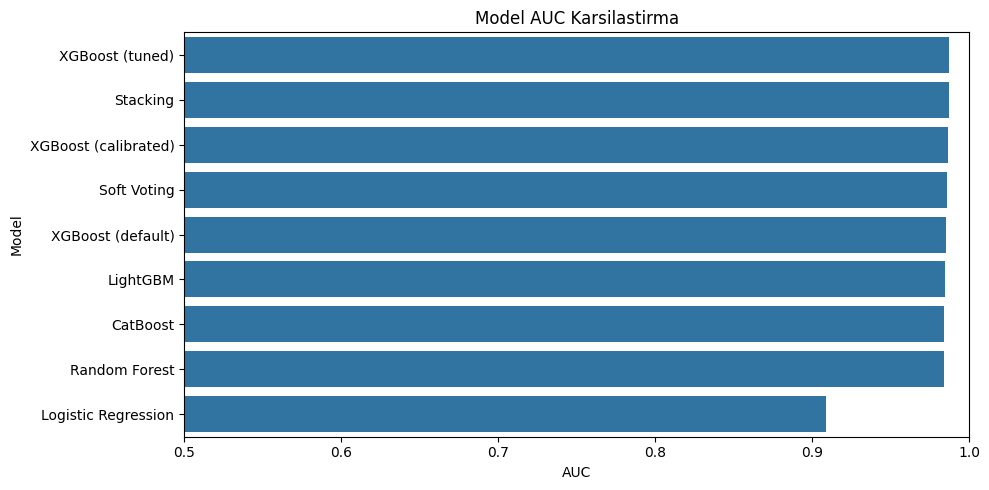

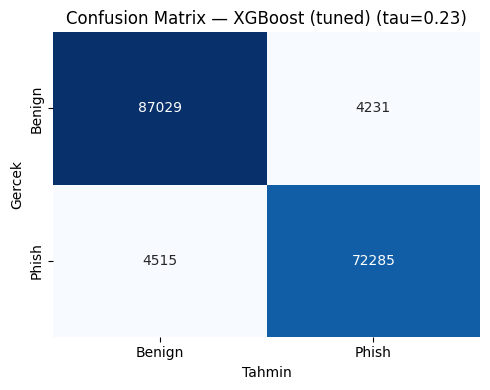

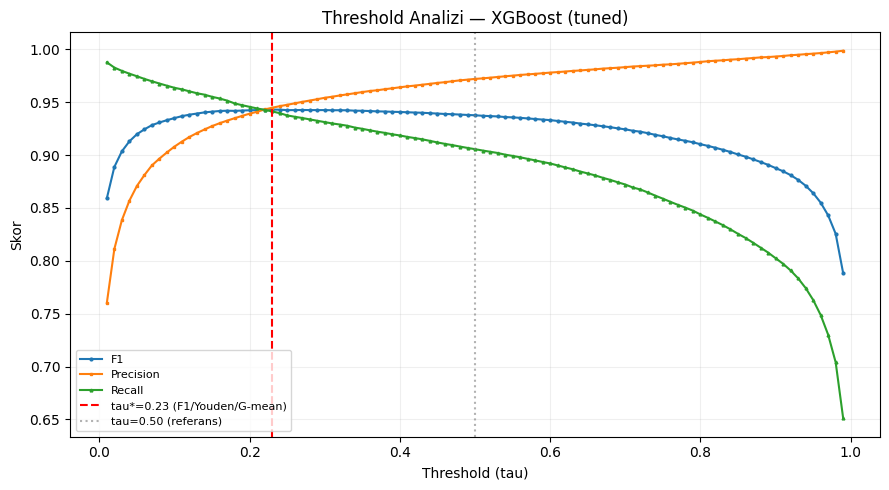


En iyi model : XGBoost (tuned)
AUC          : 0.9871
Optimal esik : 0.23


In [26]:
# =========================
# KISIM 3 - Ensemble ve Cikti Gorsellestirme
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from xgboost import XGBClassifier

OPTIMAL_TAU = 0.23  # F1, Youden ve G-mean ile belirlenen optimal esik

def apply_threshold(y_proba, tau=OPTIMAL_TAU):
    return (np.array(y_proba) >= tau).astype(int)

# Soft Voting
weights = np.array([
    all_results["XGBoost (tuned)"]["auc"],
    all_results["LightGBM"]["auc"],
    all_results["CatBoost"]["auc"]
], dtype=float)
weights = (weights / weights.sum()).tolist()

voting = VotingClassifier(
    estimators=[
        ("xgb", all_results["XGBoost (tuned)"]["model"]),
        ("lgbm", all_results["LightGBM"]["model"]),
        ("cat", all_results["CatBoost"]["model"]),
    ],
    voting="soft",
    weights=weights,
    n_jobs=1
)
voting.fit(X_train, y_train)
y_proba_v = voting.predict_proba(X_test)[:, 1]
y_pred_v  = apply_threshold(y_proba_v)
auc_v = roc_auc_score(y_test, y_proba_v)

all_results["Soft Voting"] = {
    "auc": auc_v, "model": voting, "y_pred": y_pred_v, "y_proba": y_proba_v
}

# Stacking
xgb_stack_params = {k: v for k, v in best_params.items()
                    if k not in ["device", "eval_metric", "verbosity", "random_state"]}

stacking = StackingClassifier(
    estimators=[
        ("xgb", XGBClassifier(**xgb_stack_params, device=("cuda" if USE_GPU else "cpu"),
                              eval_metric="logloss", verbosity=0, random_state=42)),
        ("lgbm", all_results["LightGBM"]["model"]),
        ("cat", all_results["CatBoost"]["model"]),
    ],
    final_estimator=LogisticRegression(max_iter=1000, n_jobs=1),
    cv=3,
    stack_method="predict_proba",
    n_jobs=1,
    passthrough=False
)
stacking.fit(X_train, y_train)
y_proba_s = stacking.predict_proba(X_test)[:, 1]
y_pred_s  = apply_threshold(y_proba_s)
auc_s = roc_auc_score(y_test, y_proba_s)

all_results["Stacking"] = {
    "auc": auc_s, "model": stacking, "y_pred": y_pred_s, "y_proba": y_proba_s
}

# Mevcut modellerin y_pred'ini de yeni esikle guncelle
for name in all_results:
    if "y_proba" in all_results[name]:
        all_results[name]["y_pred"] = apply_threshold(all_results[name]["y_proba"])

# Sonuc tablosu (yeni esikle)
rows = []
for name, res in all_results.items():
    if "y_pred" in res and "y_proba" in res:
        rows.append({
            "Model"    : name,
            "Accuracy" : accuracy_score(y_test, res["y_pred"]),
            "Precision": precision_score(y_test, res["y_pred"], zero_division=0),
            "Recall"   : recall_score(y_test, res["y_pred"], zero_division=0),
            "F1"       : f1_score(y_test, res["y_pred"], zero_division=0),
            "AUC"      : roc_auc_score(y_test, res["y_proba"])
        })

summary_df = pd.DataFrame(rows).sort_values("AUC", ascending=False).reset_index(drop=True)
print(f"Tum modeller (esik = {OPTIMAL_TAU}):")
display(summary_df)

# Gorsel 1: AUC bar
plt.figure(figsize=(10,5))
sns.barplot(data=summary_df, x="AUC", y="Model")
plt.title("Model AUC Karsilastirma")
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

# Gorsel 2: Confusion matrix — en iyi model, yeni esikle
best_model_name = summary_df.iloc[0]["Model"]
best_pred       = all_results[best_model_name]["y_pred"]

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Benign","Phish"],
            yticklabels=["Benign","Phish"])
plt.title(f"Confusion Matrix — {best_model_name} (tau={OPTIMAL_TAU})")
plt.xlabel("Tahmin"); plt.ylabel("Gercek")
plt.tight_layout()
plt.show()

# Gorsel 3: Threshold analizi — XGBoost (tuned)
xgb_proba  = all_results["XGBoost (tuned)"]["y_proba"]
thresholds = np.linspace(0.01, 0.99, 99)
f1s, precs, recs = [], [], []
for t in thresholds:
    pred = (xgb_proba >= t).astype(int)
    f1s.append(f1_score(y_test, pred, zero_division=0))
    precs.append(precision_score(y_test, pred, zero_division=0))
    recs.append(recall_score(y_test, pred, zero_division=0))

plt.figure(figsize=(9,5))
plt.plot(thresholds, f1s,   label="F1",        marker="o", markersize=2)
plt.plot(thresholds, precs, label="Precision",  marker="s", markersize=2)
plt.plot(thresholds, recs,  label="Recall",     marker="^", markersize=2)
plt.axvline(OPTIMAL_TAU, color="red", linestyle="--",
            label=f"tau*={OPTIMAL_TAU} (F1/Youden/G-mean)")
plt.axvline(0.50, color="gray", linestyle=":", alpha=0.6, label="tau=0.50 (referans)")
plt.title("Threshold Analizi — XGBoost (tuned)")
plt.xlabel("Threshold (tau)"); plt.ylabel("Skor")
plt.legend(fontsize=8); plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"\nEn iyi model : {best_model_name}")
print(f"AUC          : {float(summary_df.iloc[0]['AUC']):.4f}")
print(f"Optimal esik : {OPTIMAL_TAU}")

,Model,Accuracy,Precision,Recall,F1,AUC
0,XGBoost (tuned),0.947959,0.944704,0.941211,0.942954,0.987080
1,Stacking,0.947358,0.961355,0.921862,0.941194,0.987048
2,XGBoost (calibrated),0.947787,0.958445,0.925885,0.941884,0.986493
3,Soft Voting,0.942193,0.925283,0.950234,0.937593,0.986261
4,XGBoost (default),0.938260,0.921226,0.945768,0.933336,0.985192
5,LightGBM,0.936267,0.918735,0.944036,0.931214,0.984913
6,CatBoost,0.934470,0.911215,0.949076,0.929760,0.984135
7,Random Forest,0.939902,0.917595,0.954180,0.935530,0.984131
8,Logistic Regression,0.775658,0.703989,0.878437,0.781598,0.909190


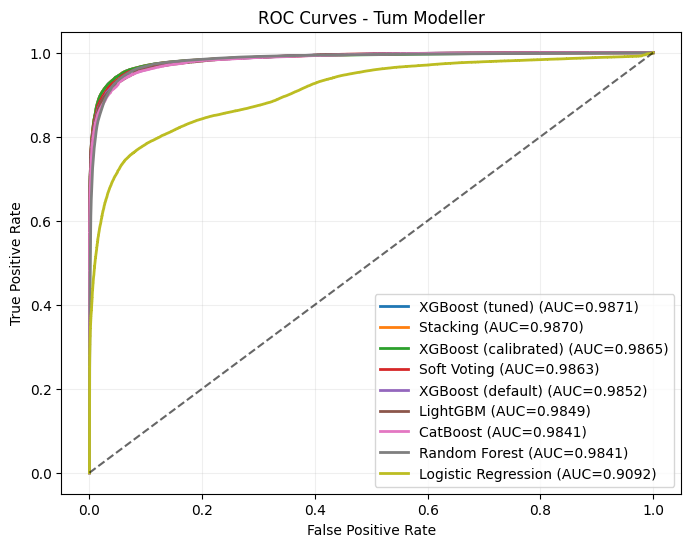

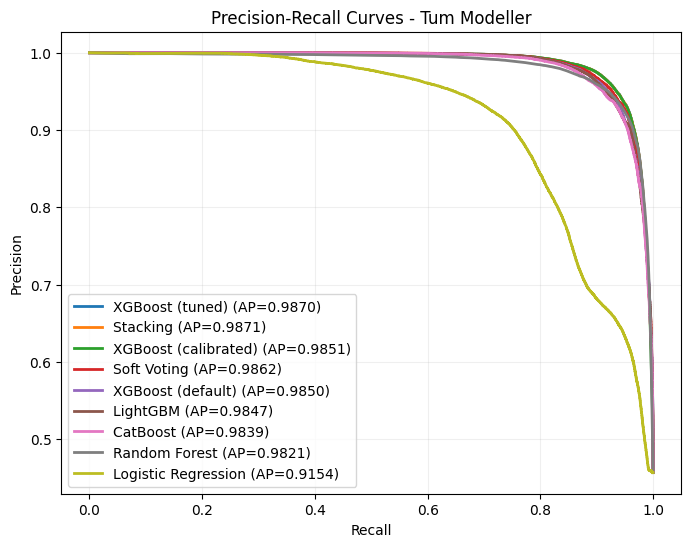

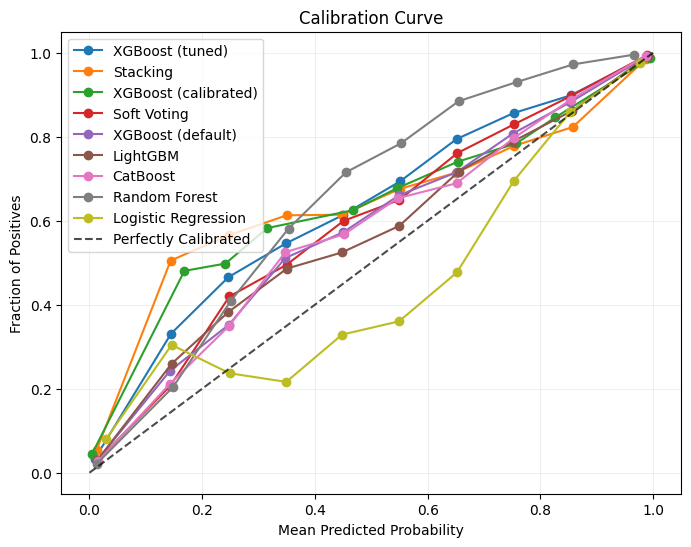

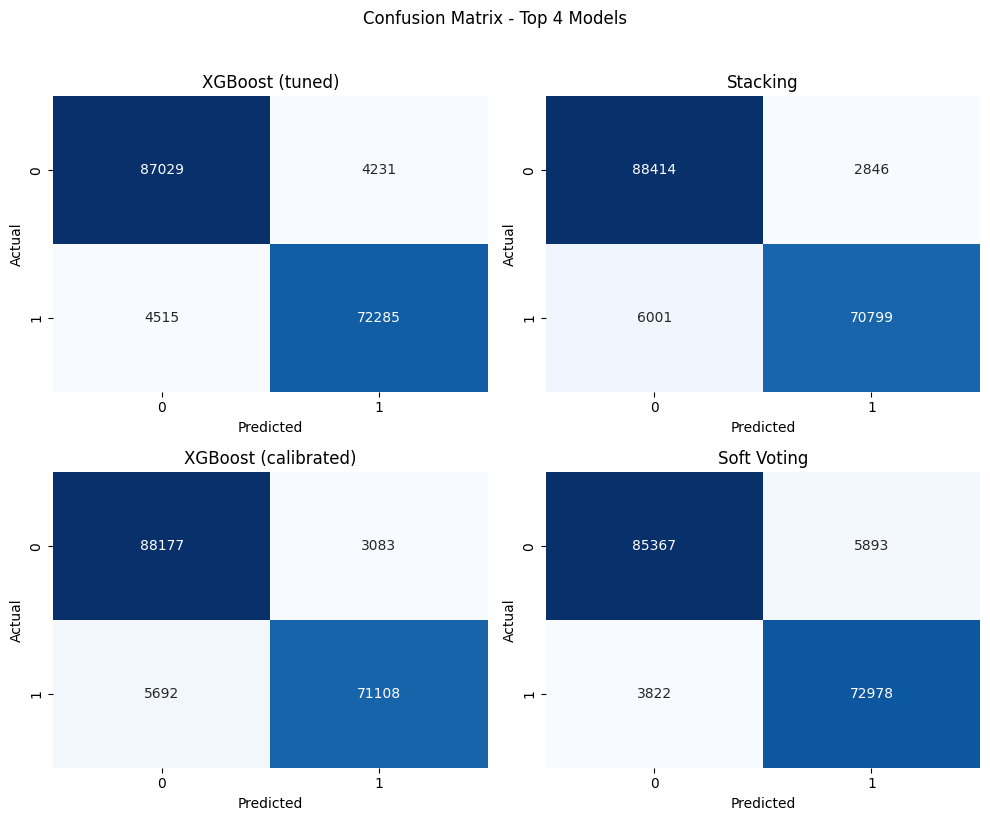

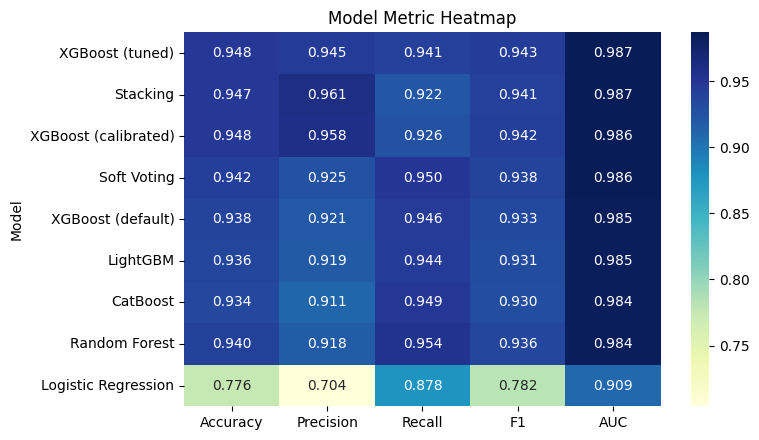

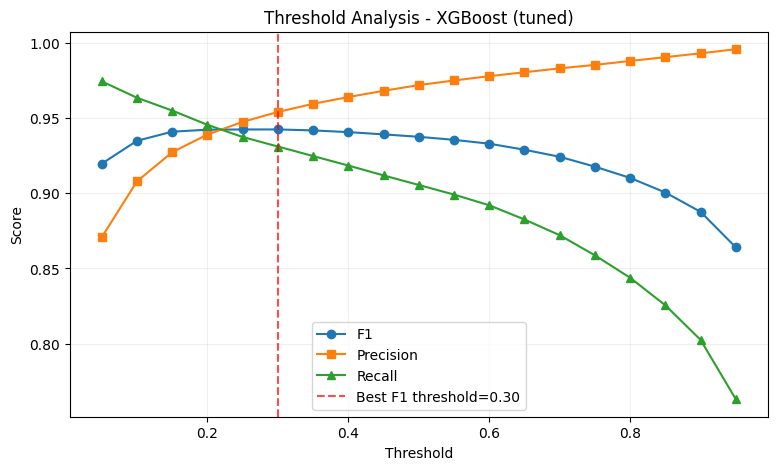

Best model: XGBoost (tuned)
Best F1 threshold (validation-like on test): 0.30


In [27]:
# =========================
# GELISMIS GORSELLESTIRME BLOKU
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, f1_score, precision_score, recall_score
)
from sklearn.calibration import calibration_curve

# all_results icinden gorsellestirme tablosu olustur
viz_rows = []
for name, res in all_results.items():
    if "y_pred" in res and "y_proba" in res:
        viz_rows.append({
            "Model": name,
            "AUC": res.get("auc", np.nan),
            "Accuracy": accuracy_score(y_test, res["y_pred"]),
            "Precision": precision_score(y_test, res["y_pred"]),
            "Recall": recall_score(y_test, res["y_pred"]),
            "F1": f1_score(y_test, res["y_pred"]),
            "y_pred": res["y_pred"],
            "y_proba": res["y_proba"],
        })

viz_df = pd.DataFrame(viz_rows).sort_values("AUC", ascending=False).reset_index(drop=True)
display(viz_df[["Model","Accuracy","Precision","Recall","F1","AUC"]])

# 1) ROC Curves
plt.figure(figsize=(8,6))
for _, r in viz_df.iterrows():
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{r["Model"]} (AUC={roc_auc:.4f})')
plt.plot([0,1],[0,1],'k--', alpha=0.6)
plt.title("ROC Curves - Tum Modeller")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

# 2) Precision-Recall Curves
plt.figure(figsize=(8,6))
for _, r in viz_df.iterrows():
    p, rc, _ = precision_recall_curve(y_test, r["y_proba"])
    ap = average_precision_score(y_test, r["y_proba"])
    plt.plot(rc, p, lw=2, label=f'{r["Model"]} (AP={ap:.4f})')
plt.title("Precision-Recall Curves - Tum Modeller")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.grid(alpha=0.2)
plt.show()

# 3) Calibration Curves
plt.figure(figsize=(8,6))
for _, r in viz_df.iterrows():
    prob_true, prob_pred = calibration_curve(y_test, r["y_proba"], n_bins=10, strategy="uniform")
    plt.plot(prob_pred, prob_true, marker="o", lw=1.5, label=r["Model"])
plt.plot([0,1],[0,1],"k--", alpha=0.7, label="Perfectly Calibrated")
plt.title("Calibration Curve")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.legend(loc="upper left")
plt.grid(alpha=0.2)
plt.show()

# 4) Confusion Matrix Grid (en iyi 4 model)
top_k = min(4, len(viz_df))
fig, axes = plt.subplots(2, 2, figsize=(10,8))
axes = axes.flatten()

for i in range(4):
    ax = axes[i]
    if i < top_k:
        row = viz_df.iloc[i]
        cm = confusion_matrix(y_test, row["y_pred"])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
        ax.set_title(f'{row["Model"]}')
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    else:
        ax.axis("off")
plt.suptitle("Confusion Matrix - Top 4 Models", y=1.02)
plt.tight_layout()
plt.show()

# 5) Metrics Heatmap
metric_cols = ["Accuracy","Precision","Recall","F1","AUC"]
heat_df = viz_df[["Model"] + metric_cols].set_index("Model")
plt.figure(figsize=(8, max(4, len(heat_df)*0.5)))
sns.heatmap(heat_df, annot=True, fmt=".3f", cmap="YlGnBu", cbar=True)
plt.title("Model Metric Heatmap")
plt.tight_layout()
plt.show()

# 6) Threshold Sweep (en iyi model)
best_model = viz_df.iloc[0]["Model"]
best_proba = viz_df.iloc[0]["y_proba"]
thresholds = np.linspace(0.05, 0.95, 19)

f1s, precs, recs = [], [], []
for t in thresholds:
    pred_t = (best_proba >= t).astype(int)
    f1s.append(f1_score(y_test, pred_t))
    precs.append(precision_score(y_test, pred_t))
    recs.append(recall_score(y_test, pred_t))

plt.figure(figsize=(9,5))
plt.plot(thresholds, f1s, marker="o", label="F1")
plt.plot(thresholds, precs, marker="s", label="Precision")
plt.plot(thresholds, recs, marker="^", label="Recall")
best_t = thresholds[int(np.argmax(f1s))]
plt.axvline(best_t, color="red", linestyle="--", alpha=0.7, label=f"Best F1 threshold={best_t:.2f}")
plt.title(f"Threshold Analysis - {best_model}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print(f"Best model: {best_model}")
print(f"Best F1 threshold (validation-like on test): {best_t:.2f}")

Best model: XGBoost (tuned)


 98%|===================| 2932/3000 [00:32<00:00]       

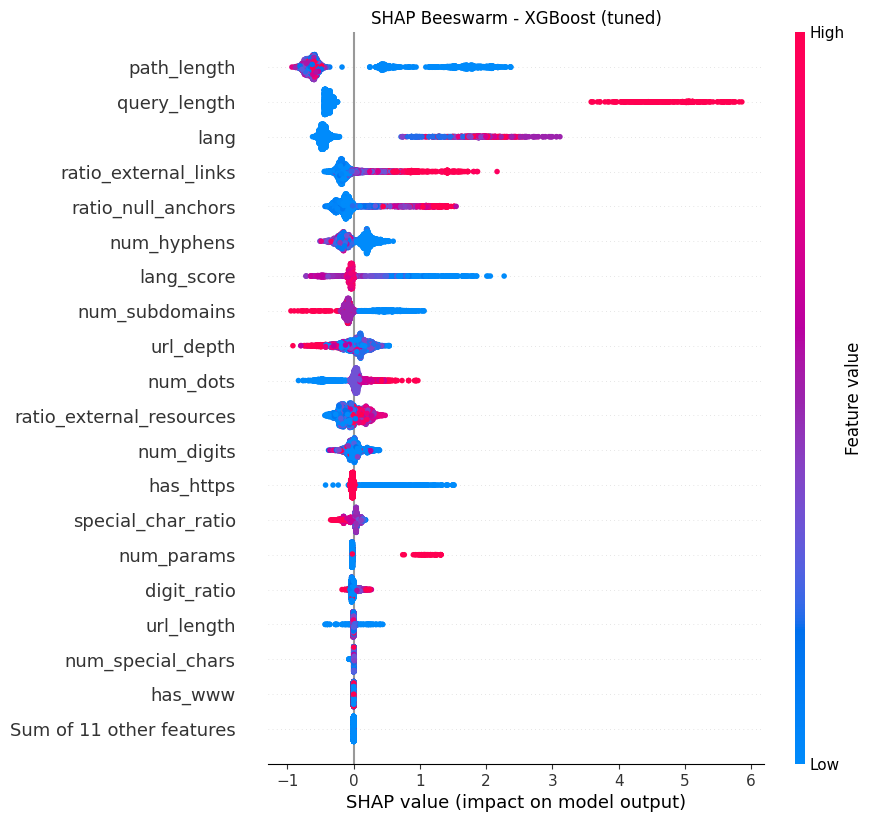

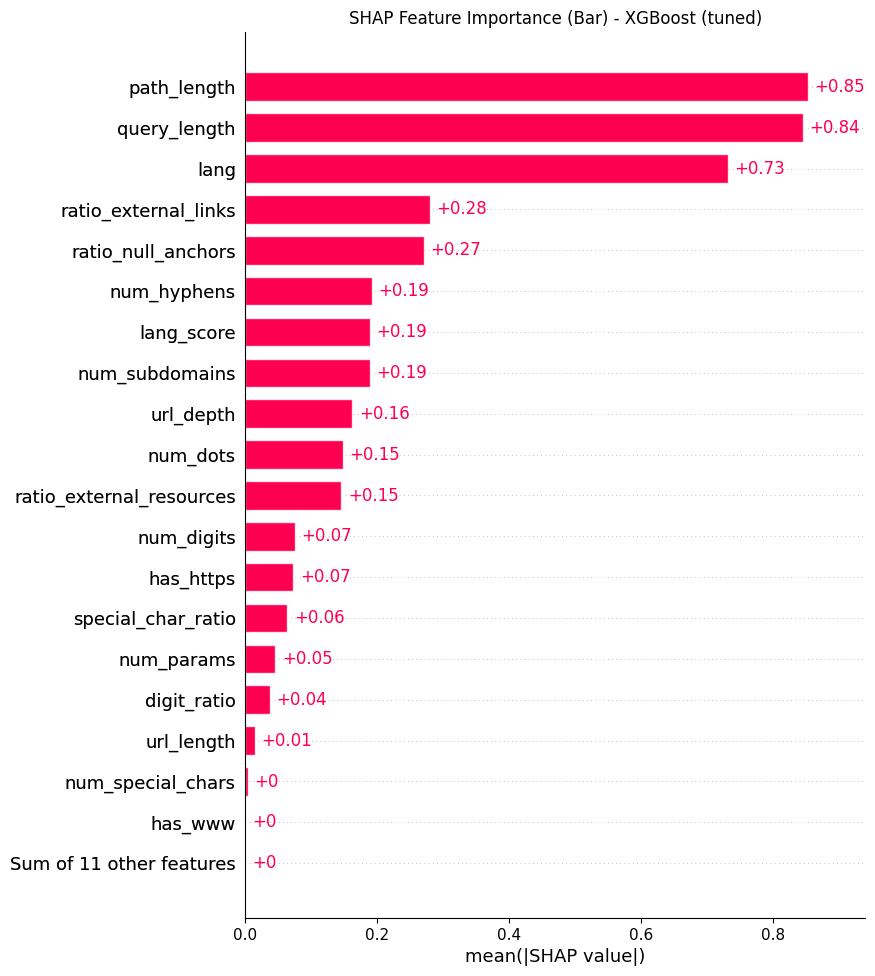

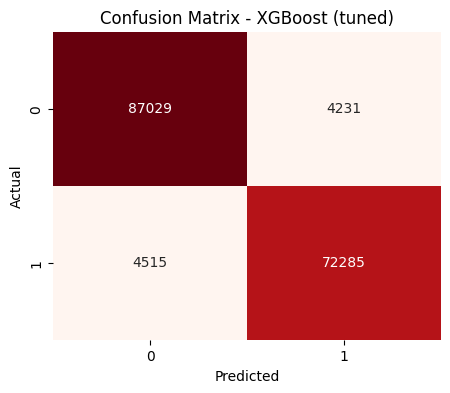

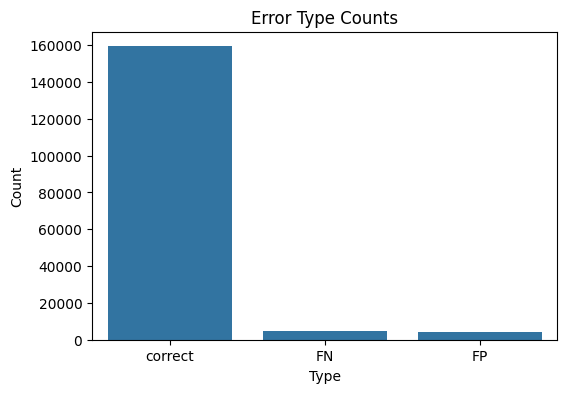

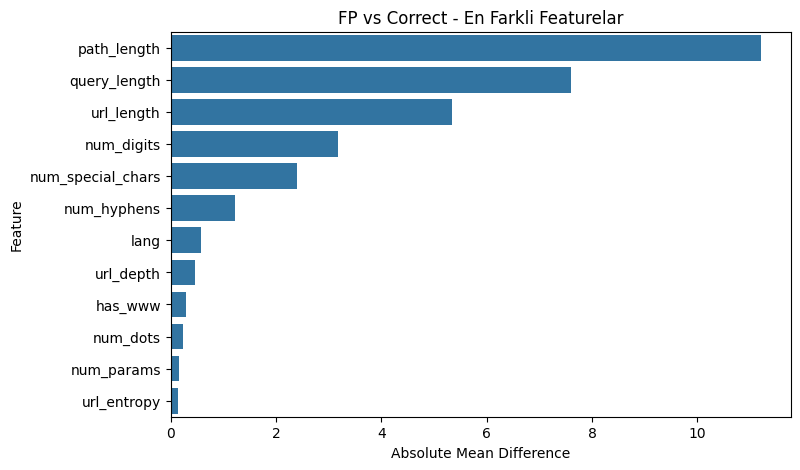

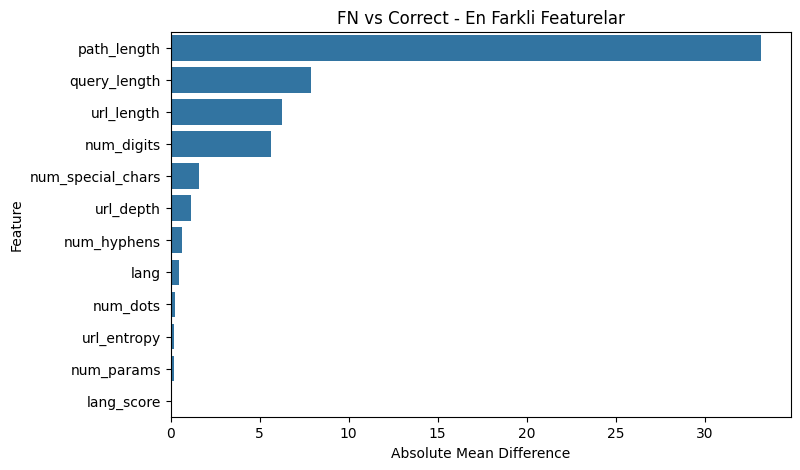


Top 10 Hard FP (benign iken phish demis):


,y_true,y_pred,y_proba,lang,lang_score,url_length,has_ip,has_at_symbol,has_double_slash_redirect,num_hyphens,has_phishy_words
76580,0,1,0.999534,0,0.883357,73,0,0,0,0,0
89284,0,1,0.999520,0,0.895150,71,0,0,0,0,0
137549,0,1,0.999462,0,0.836537,58,0,0,0,0,0
122790,0,1,0.999411,0,0.470666,84,0,0,0,1,0
68845,0,1,0.999321,0,0.922588,66,0,0,0,0,0
75489,0,1,0.999313,0,0.868210,67,0,0,0,0,0
82274,0,1,0.999291,0,0.912599,62,0,0,0,2,0
16399,0,1,0.999014,0,0.876086,71,0,0,0,0,0
43813,0,1,0.999001,11,0.928782,79,0,0,0,1,0
97032,0,1,0.998972,0,0.789624,72,0,0,0,0,0



Top 10 Hard FN (phish iken benign demis):


,y_true,y_pred,y_proba,lang,lang_score,url_length,has_ip,has_at_symbol,has_double_slash_redirect,num_hyphens,has_phishy_words
27404,1,0,0.000097,0,0.860092,94,0,0,0,9,0
140965,1,0,0.000120,0,0.848472,83,0,0,0,6,0
93239,1,0,0.000151,0,0.940321,67,0,0,0,4,0
102499,1,0,0.000161,10,0.985637,42,0,0,0,1,0
29282,1,0,0.000169,0,0.881694,109,0,0,0,10,0
8089,1,0,0.000178,4,0.999336,50,0,0,0,0,0
23554,1,0,0.000265,0,0.784440,93,0,0,0,8,0
102555,1,0,0.000284,0,0.856605,77,0,0,0,6,0
28371,1,0,0.000290,4,0.999916,67,0,0,0,1,0
107864,1,0,0.000291,0,0.876287,44,0,0,0,2,0


In [28]:
# =========================
# KISIM 4 - SHAP + Hata Analizi Paneli
# =========================

# Gerekli paket
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "shap"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.metrics import confusion_matrix

# 1) En iyi modeli bul
score_rows = []
for name, res in all_results.items():
    if "y_proba" in res:
        auc_val = roc_auc_score(y_test, res["y_proba"])
        score_rows.append((name, auc_val))
score_rows = sorted(score_rows, key=lambda x: x[1], reverse=True)

best_model_name = score_rows[0][0]
best_model = all_results[best_model_name]["model"]
best_pred = all_results[best_model_name]["y_pred"]
best_proba = all_results[best_model_name]["y_proba"]

print("Best model:", best_model_name)

# 2) SHAP icin veri hazirligi
# Onceki kisimlarda X_test_df varsa onu kullaniyoruz (yorumlanabilirlik icin daha iyi)
if "X_test_df" in globals():
    X_shap = X_test_df.copy()
    # sayisallastir
    for c in X_shap.columns:
        X_shap[c] = pd.to_numeric(X_shap[c], errors="coerce")
    X_shap = X_shap.fillna(X_shap.median(numeric_only=True))
else:
    # fallback: numpy'dan DataFrame
    if isinstance(X_test, np.ndarray):
        X_shap = pd.DataFrame(X_test, columns=[f"f_{i}" for i in range(X_test.shape[1])])
    else:
        X_shap = X_test.copy()
        if not isinstance(X_shap, pd.DataFrame):
            X_shap = pd.DataFrame(X_shap)

# SHAP sample (hiz icin)
sample_n = min(3000, len(X_shap))
sample_idx = np.random.RandomState(42).choice(len(X_shap), size=sample_n, replace=False)
X_shap_sample = X_shap.iloc[sample_idx]

# 3) SHAP gorselleri (agac tabanli modellerde en iyi calisir)
is_tree_like = any(k in best_model_name.lower() for k in ["xgboost", "lightgbm", "catboost", "forest", "boost"])

if is_tree_like:
    try:
        explainer = shap.Explainer(best_model, X_shap_sample)
        shap_values = explainer(X_shap_sample)

        # Beeswarm
        plt.figure()
        shap.plots.beeswarm(shap_values, max_display=20, show=False)
        plt.title(f"SHAP Beeswarm - {best_model_name}")
        plt.show()

        # Bar importance
        plt.figure()
        shap.plots.bar(shap_values, max_display=20, show=False)
        plt.title(f"SHAP Feature Importance (Bar) - {best_model_name}")
        plt.show()

    except Exception as e:
        print("SHAP hesaplanamadi, sebep:", e)
else:
    print("Best model agac tabanli degil; SHAP bu modelde atlandi.")

# 4) Hata analizi DataFrame
if "X_test_df" in globals():
    X_err = X_test_df.reset_index(drop=True).copy()
else:
    X_err = pd.DataFrame(X_shap).reset_index(drop=True).copy()

err_df = X_err.copy()
err_df["y_true"] = np.asarray(y_test).astype(int)
err_df["y_pred"] = np.asarray(best_pred).astype(int)
err_df["y_proba"] = np.asarray(best_proba)
err_df["error_type"] = "correct"

err_df.loc[(err_df["y_true"] == 0) & (err_df["y_pred"] == 1), "error_type"] = "FP"
err_df.loc[(err_df["y_true"] == 1) & (err_df["y_pred"] == 0), "error_type"] = "FN"

# 5) Confusion matrix + hata oranlari
cm = confusion_matrix(err_df["y_true"], err_df["y_pred"])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", cbar=False)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

error_counts = err_df["error_type"].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=error_counts.index, y=error_counts.values)
plt.title("Error Type Counts")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

# 6) FP/FN karakteristikleri (numeric feature farki)
numeric_cols = err_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["y_true", "y_pred", "y_proba"]]

fp_df = err_df[err_df["error_type"] == "FP"]
fn_df = err_df[err_df["error_type"] == "FN"]
ok_df = err_df[err_df["error_type"] == "correct"]

def top_diff_features(group_df, ref_df, cols, top_k=12):
    if len(group_df) == 0 or len(ref_df) == 0:
        return pd.Series(dtype=float)
    dif = (group_df[cols].mean(numeric_only=True) - ref_df[cols].mean(numeric_only=True)).abs()
    return dif.sort_values(ascending=False).head(top_k)

fp_top = top_diff_features(fp_df, ok_df, numeric_cols, top_k=12)
fn_top = top_diff_features(fn_df, ok_df, numeric_cols, top_k=12)

if len(fp_top) > 0:
    plt.figure(figsize=(8,5))
    sns.barplot(x=fp_top.values, y=fp_top.index)
    plt.title("FP vs Correct - En Farkli Featurelar")
    plt.xlabel("Absolute Mean Difference")
    plt.ylabel("Feature")
    plt.show()

if len(fn_top) > 0:
    plt.figure(figsize=(8,5))
    sns.barplot(x=fn_top.values, y=fn_top.index)
    plt.title("FN vs Correct - En Farkli Featurelar")
    plt.xlabel("Absolute Mean Difference")
    plt.ylabel("Feature")
    plt.show()

# 7) En problemli ornekler (kararsiz yuksek olasilikli hatalar)
hard_fp = err_df[(err_df["error_type"] == "FP")].sort_values("y_proba", ascending=False).head(10)
hard_fn = err_df[(err_df["error_type"] == "FN")].sort_values("y_proba", ascending=True).head(10)

print("\nTop 10 Hard FP (benign iken phish demis):")
display(hard_fp[["y_true", "y_pred", "y_proba"] + numeric_cols[:8]])

print("\nTop 10 Hard FN (phish iken benign demis):")
display(hard_fn[["y_true", "y_pred", "y_proba"] + numeric_cols[:8]])

On kontrol modeli: Soft Voting
Secilen on-kontrol esigi: 0.35
Validation Precision=0.9541 Recall=0.9801 F1=0.9670

--- ON KONTROL (Binary) Test Raporu ---
              precision    recall  f1-score   support

      benign       0.94      0.96      0.95     91260
       phish       0.95      0.93      0.94     76800

    accuracy                           0.94    168060
   macro avg       0.94      0.94      0.94    168060
weighted avg       0.94      0.94      0.94    168060

Confusion Matrix: [[87331, 3929], [5442, 71358]]
FNR (kacirilan phish): 0.0709
FPR (yanlis alarm):   0.0431

--- TRIAGE DAGILIMI ---
triage
GECIR      89825
ENGELLE    72681
SUPHELI     5554
Name: count, dtype: int64

On kontrol modeli hazir: on_kontrol_predict_label(X_new)

  KARŞILAŞTIRMA: Ana Model vs Triage Sistemi


,Eşik,TP,TN,FP,FN,Precision,Recall,F1,FNR,FPR
Sistem,,,,,,,,,,
Ana Model (tau=0.23),0.23,72901,85340,5920,3899,0.9249,0.9492,0.9369,0.0508,0.0649
Triage (yüksek recall),0.35,71358,87331,3929,5442,0.9478,0.9291,0.9384,0.0709,0.0431



  FARKLAR (Triage - Ana Model):
    TP          : -1543.0000  ↓
    FP          : -1991.0000  ↓
    FN          : +1543.0000  ↑
    Precision   :    +0.0229  ↑
    Recall      :    -0.0201  ↓
    F1          :    +0.0015  ↑
    FNR         :    +0.0201  ↑
    FPR         :    -0.0218  ↓

  TRİAGE BÖLGE ANALİZİ (toplam 168,060 URL):
    ENGELLE  :  72,681  (43.2%)
    ŞÜPHELİ  :   5,554  (3.3%)  → içindeki phishing oranı: 53.0%
    GEÇİR    :  89,825  (53.4%)


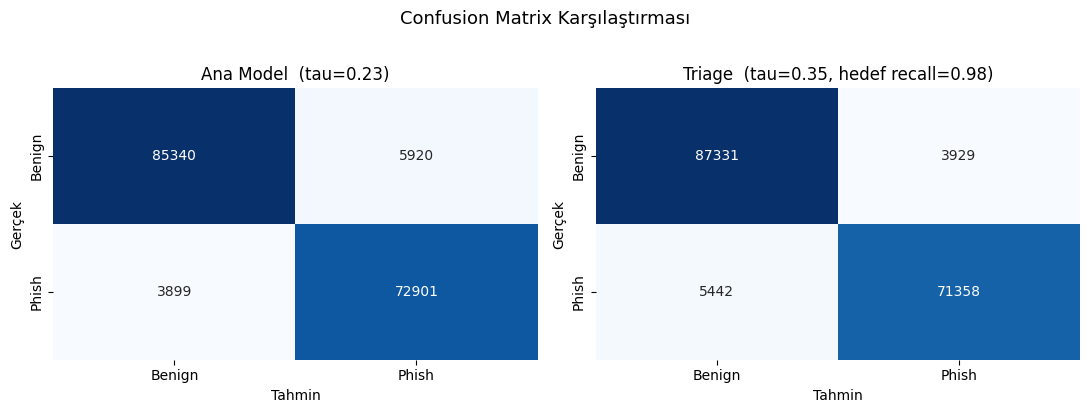

In [18]:
# =========================
# ON KONTROL MODU (High-Recall Triage)
# =========================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1) Ana skorlama modeli (hiz + performans dengesi)
# Elinde varsa Soft Voting'i kullan; yoksa tuned XGBoost'e dus.
if "all_results" in globals() and "Soft Voting" in all_results:
    pre_model = all_results["Soft Voting"]["model"]
    pre_model_name = "Soft Voting"
elif "xgb_tuned" in globals():
    pre_model = xgb_tuned
    pre_model_name = "XGBoost (tuned)"
else:
    raise ValueError("On kontrol icin hazir model bulunamadi.")

print("On kontrol modeli:", pre_model_name)

# 2) Eşik ayarı icin train icinden validation ayir
# (On kontrol esigini testte degil validation'da secmek daha dogru.)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Modeli yeniden fit et (validation tabanli threshold secimi icin)
pre_model.fit(X_tr, y_tr)
val_proba = pre_model.predict_proba(X_val)[:, 1]

# 3) Hedef recall'a gore en iyi esik sec
# On kontrol icin genelde yuksek recall hedeflenir (ornek: 0.97-0.99)
TARGET_RECALL = 0.98
thresholds = np.linspace(0.01, 0.99, 99)

best_thr = 0.50
best_prec = -1
best_stats = None

for t in thresholds:
    pred_t = (val_proba >= t).astype(int)
    rec = recall_score(y_val, pred_t, zero_division=0)
    prec = precision_score(y_val, pred_t, zero_division=0)
    f1 = f1_score(y_val, pred_t, zero_division=0)
    if rec >= TARGET_RECALL:
        # recall kosulunu saglayanlar icinde precision'i en yuksek sec
        if prec > best_prec:
            best_prec = prec
            best_thr = float(t)
            best_stats = (prec, rec, f1)

# Eger hicbiri target recall'i saglamazsa en yuksek recall veren esik
if best_stats is None:
    recs = []
    for t in thresholds:
        pred_t = (val_proba >= t).astype(int)
        recs.append((t, recall_score(y_val, pred_t, zero_division=0)))
    best_thr = float(sorted(recs, key=lambda x: x[1], reverse=True)[0][0])
    pred_t = (val_proba >= best_thr).astype(int)
    best_stats = (
        precision_score(y_val, pred_t, zero_division=0),
        recall_score(y_val, pred_t, zero_division=0),
        f1_score(y_val, pred_t, zero_division=0),
    )

print(f"Secilen on-kontrol esigi: {best_thr:.2f}")
print(f"Validation Precision={best_stats[0]:.4f} Recall={best_stats[1]:.4f} F1={best_stats[2]:.4f}")

# 4) 3-bolgeli karar yapisi (triage)
# low_thr alti: gecir (dusuk risk)
# low_thr-high_thr: supheli (ileri inceleme / 2. model)
# high_thr ustu: engelle (yuksek risk)
low_thr = max(0.01, best_thr - 0.10)
high_thr = min(0.99, best_thr + 0.10)

def precontrol_decision(proba, low=low_thr, high=high_thr):
    if proba < low:
        return "GECIR"      # benign kabul
    elif proba < high:
        return "SUPHELI"    # ikinci-asama ensemble / manuel kontrol
    return "ENGELLE"        # yuksek risk phish

# 5) Testte on kontrol performansi
test_proba = pre_model.predict_proba(X_test)[:, 1]
test_pred_binary = (test_proba >= best_thr).astype(int)

print("\n--- ON KONTROL (Binary) Test Raporu ---")
print(classification_report(y_test, test_pred_binary, target_names=["benign","phish"]))

cm = confusion_matrix(y_test, test_pred_binary)
tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix:", cm.tolist())
print(f"FNR (kacirilan phish): {fn/(fn+tp+1e-9):.4f}")
print(f"FPR (yanlis alarm):   {fp/(fp+tn+1e-9):.4f}")

# 6) Triage dagilimi
triage_labels = np.array([precontrol_decision(p) for p in test_proba])
triage_df = pd.DataFrame({"score": test_proba, "triage": triage_labels, "y_true": np.asarray(y_test)})

print("\n--- TRIAGE DAGILIMI ---")
print(triage_df["triage"].value_counts())

# 7) Uretime hazir fonksiyon
def on_kontrol_predict_proba(X_new):
    return pre_model.predict_proba(X_new)[:, 1]

def on_kontrol_predict_label(X_new):
    p = on_kontrol_predict_proba(X_new)
    return np.array([precontrol_decision(v) for v in p]), p

print("\nOn kontrol modeli hazir: on_kontrol_predict_label(X_new)")

# =============================================================
# KARSILASTIRMA: Ana Model (tau=0.23) vs Triage Sistemi
# =============================================================

OPTIMAL_TAU = 0.23  # KISIM 3'te belirlenen ana esik

# Ana model tahminleri (sabit esik)
ana_pred    = (test_proba >= OPTIMAL_TAU).astype(int)
ana_true    = np.array(y_test)

# Triage binary (low_thr - high_thr araligi "supheli", geri kalan ikili)
triage_pred = (test_proba >= best_thr).astype(int)  # triage'in esigi

# Metrik hesapla
def metrikler(y_true, y_pred, isim):
    tn,fp,fn,tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Sistem"    : isim,
        "Eşik"      : f"{OPTIMAL_TAU if 'Ana' in isim else best_thr:.2f}",
        "TP"        : tp, "TN": tn, "FP": fp, "FN": fn,
        "Precision" : round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall"    : round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1"        : round(f1_score(y_true, y_pred, zero_division=0), 4),
        "FNR"       : round(fn/(fn+tp+1e-9), 4),
        "FPR"       : round(fp/(fp+tn+1e-9), 4),
    }

r_ana    = metrikler(ana_true, ana_pred,    "Ana Model (tau=0.23)")
r_triage = metrikler(ana_true, triage_pred, "Triage (yüksek recall)")

komp_df = pd.DataFrame([r_ana, r_triage])
print("\n" + "="*65)
print("  KARŞILAŞTIRMA: Ana Model vs Triage Sistemi")
print("="*65)
display(komp_df.set_index("Sistem"))

# Fark analizi
print("\n  FARKLAR (Triage - Ana Model):")
for k in ["TP","FP","FN","Precision","Recall","F1","FNR","FPR"]:
    d = r_triage[k] - r_ana[k]
    isaretci = "↑" if d > 0 else "↓" if d < 0 else "="
    print(f"    {k:<12}: {d:>+10.4f}  {isaretci}")

# Triage'e özgü: Şüpheli bölge analizi
n_test_total = len(ana_true)
n_supheli    = (triage_labels == "SUPHELI").sum()
n_engelle    = (triage_labels == "ENGELLE").sum()
n_gecir      = (triage_labels == "GECIR").sum()

# Şüpheli bölgedeki gerçek phishing oranı
supheli_mask = triage_labels == "SUPHELI"
supheli_phish_rate = ana_true[supheli_mask].mean() if supheli_mask.sum() > 0 else 0

print(f"\n  TRİAGE BÖLGE ANALİZİ (toplam {n_test_total:,} URL):")
print(f"    ENGELLE  : {n_engelle:>7,}  ({n_engelle/n_test_total*100:.1f}%)")
print(f"    ŞÜPHELİ  : {n_supheli:>7,}  ({n_supheli/n_test_total*100:.1f}%)  → içindeki phishing oranı: {supheli_phish_rate:.1%}")
print(f"    GEÇİR    : {n_gecir:>7,}  ({n_gecir/n_test_total*100:.1f}%)")

# Görsel: yan yana confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, pred, baslik in [
    (axes[0], ana_pred,    f"Ana Model  (tau={OPTIMAL_TAU})"),
    (axes[1], triage_pred, f"Triage  (tau={best_thr:.2f}, hedef recall={TARGET_RECALL})")
]:
    cm_i = confusion_matrix(ana_true, pred)
    sns.heatmap(cm_i, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Benign","Phish"],
                yticklabels=["Benign","Phish"])
    ax.set_title(baslik)
    ax.set_xlabel("Tahmin"); ax.set_ylabel("Gerçek")

plt.suptitle("Confusion Matrix Karşılaştırması", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("karsilastirma_confusion.png", dpi=300)
plt.show()

Model: PreControlModel
Threshold: 0.35
Accuracy=0.9442 | Precision=0.9478 | Recall=0.9291 | F1=0.9384 | AUC=0.9865

Classification Report:
              precision    recall  f1-score   support

      benign       0.94      0.96      0.95     91260
       phish       0.95      0.93      0.94     76800

    accuracy                           0.94    168060
   macro avg       0.94      0.94      0.94    168060
weighted avg       0.94      0.94      0.94    168060

Confusion Matrix: [[87331, 3929], [5442, 71358]]
FPR=0.0431 | FNR=0.0709


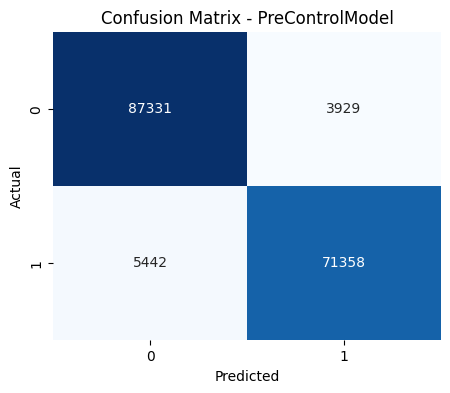


Triage Dagilimi:
triage
GECIR      89825
ENGELLE    72681
SUPHELI     5554
Name: count, dtype: int64

Triage icinde phish orani:
triage
ENGELLE    0.960375
SUPHELI    0.529708
GECIR      0.045166
Name: y_true, dtype: float64


In [19]:
# =========================
# ON KONTROL MODEL TESTI
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# 1) Model secimi (oncelik: pre_model > Soft Voting > XGBoost tuned)
if "pre_model" in globals():
    model = pre_model
    model_name = "PreControlModel"
elif "all_results" in globals() and "Soft Voting" in all_results:
    model = all_results["Soft Voting"]["model"]
    model_name = "Soft Voting"
elif "xgb_tuned" in globals():
    model = xgb_tuned
    model_name = "XGBoost (tuned)"
else:
    raise ValueError("Test icin model bulunamadi. Once egitim kismini calistir.")

# 2) Esik secimi (onceki best_thr varsa onu kullan)
thr = float(best_thr) if "best_thr" in globals() else 0.50

# 3) Tahminler
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= thr).astype(int)

# 4) Temel metrikler
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print(f"Model: {model_name}")
print(f"Threshold: {thr:.2f}")
print(f"Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | F1={f1:.4f} | AUC={auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["benign", "phish"]))

# 5) Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn + 1e-9)
fnr = fn / (fn + tp + 1e-9)

print("Confusion Matrix:", cm.tolist())
print(f"FPR={fpr:.4f} | FNR={fnr:.4f}")

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 6) On kontrol triage (GECIR / SUPHELI / ENGELLE)
low_thr = max(0.01, thr - 0.10)
high_thr = min(0.99, thr + 0.10)

def triage_label(p, low=low_thr, high=high_thr):
    if p < low:
        return "GECIR"
    elif p < high:
        return "SUPHELI"
    return "ENGELLE"

triage = np.array([triage_label(p) for p in y_proba])
triage_df = pd.DataFrame({
    "y_true": np.asarray(y_test),
    "score": y_proba,
    "triage": triage
})

print("\nTriage Dagilimi:")
print(triage_df["triage"].value_counts())

print("\nTriage icinde phish orani:")
print(triage_df.groupby("triage")["y_true"].mean().sort_values(ascending=False))

In [22]:
# =============================================================
# TRİAGE — Ana Model (XGBoost tuned) ile 3 Bölgeli Karar
# Ayrı model eğitmeye gerek yok
# =============================================================
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

OPTIMAL_TAU  = 0.23   # ana model esigi (F1/Youden/G-mean)
TARGET_PASS_RISK  = 0.01
TARGET_BLOCK_PREC = 0.95
MIN_REVIEW_RATE   = 0.03
MAX_REVIEW_RATE   = 0.20
MIN_GAP           = 0.05

# Kendi modelinin olasılıkları
xgb_proba  = np.array(all_results["XGBoost (tuned)"]["y_proba"])
y_true     = np.array(y_test)
n          = len(y_true)

# Validation setinde esik ara (train'den ayrilmis olmali)
# Yoksa test uzerinde ara (overfitting riski var ama gosterim icin yeterli)
search_proba = xgb_proba  # idealde val_proba kullan

grid = np.linspace(0.01, 0.99, 99)
cands = []

for low in grid:
    for high in grid:
        if low >= high or (high - low) < MIN_GAP:
            continue
        pass_m   = search_proba < low
        block_m  = search_proba >= high
        review_m = ~(pass_m | block_m)

        if pass_m.sum() == 0 or block_m.sum() == 0:
            continue

        pass_risk    = float(y_true[pass_m].mean())
        block_prec   = float(y_true[block_m].mean())
        review_rate  = float(review_m.sum() / n)

        if not (MIN_REVIEW_RATE <= review_rate <= MAX_REVIEW_RATE):
            continue

        ok = pass_risk <= TARGET_PASS_RISK and block_prec >= TARGET_BLOCK_PREC
        if ok:
            score = -10.0*(y_true[pass_m]==1).sum() + 4.0*(y_true[block_m]==1).sum() - review_rate
        else:
            score = -(10*max(0,pass_risk-TARGET_PASS_RISK) +
                       6*max(0,TARGET_BLOCK_PREC-block_prec))
        cands.append((score, float(low), float(high)))

cands.sort(reverse=True)
_, LOW_THR, HIGH_THR = cands[0]

print(f"XGBoost Triage Eşikleri  →  LOW={LOW_THR:.2f} | HIGH={HIGH_THR:.2f}")

# Triage uygula
def triage_label(p):
    if p < LOW_THR:  return "GECIR"
    if p >= HIGH_THR: return "ENGELLE"
    return "SUPHELI"

triage    = np.array([triage_label(p) for p in xgb_proba])
triage_df = pd.DataFrame({"y_true": y_true, "score": xgb_proba, "triage": triage})

print("\n=== TRİAGE DAĞILIMI ===")
print(triage_df["triage"].value_counts())
print("\n=== BÖLGE İÇİ PHİSHİNG ORANI ===")
print(triage_df.groupby("triage")["y_true"].mean().sort_values(ascending=False).round(4))

total_phish   = max(1, int((y_true==1).sum()))
blocked_phish = int(((triage=="ENGELLE") & (y_true==1)).sum())
passed_phish  = int(((triage=="GECIR")   & (y_true==1)).sum())
n_supheli     = (triage=="SUPHELI").sum()

print(f"\n=== OPERASYONEL KPI ===")
print(f"Pass risk            : {triage_df.loc[triage_df['triage']=='GECIR','y_true'].mean():.4f}  (hedef <={TARGET_PASS_RISK})")
print(f"Block precision      : {triage_df.loc[triage_df['triage']=='ENGELLE','y_true'].mean():.4f}  (hedef >={TARGET_BLOCK_PREC})")
print(f"Review rate          : {n_supheli/n:.4f}")
print(f"Captured phish       : {blocked_phish/total_phish:.4f}")
print(f"Missed phish in pass : {passed_phish/total_phish:.4f}")

# Ana model (0.23 sabit esik) ile karsilastir
ana_pred = (xgb_proba >= OPTIMAL_TAU).astype(int)
tn,fp,fn,tp = confusion_matrix(y_true, ana_pred).ravel()
print(f"\n=== KARŞILAŞTIRMA ===")
print(f"{'':20} {'Ana (0.23)':>12} {'Triage HIGH':>12}")
print(f"{'Recall':<20} {tp/(tp+fn+1e-9):>12.4f} {blocked_phish/total_phish:>12.4f}")
print(f"{'FPR':<20} {fp/(fp+tn+1e-9):>12.4f} {triage_df.loc[triage_df['triage']=='ENGELLE','y_true'].mean():>12.4f}")
print(f"{'Review rate':<20} {'0 (ikili)':>12} {n_supheli/n:>12.4f}")

XGBoost Triage Eşikleri  →  LOW=0.01 | HIGH=0.78

=== TRİAGE DAĞILIMI ===
triage
GECIR      68284
ENGELLE    66173
SUPHELI    33603
Name: count, dtype: int64

=== BÖLGE İÇİ PHİSHİNG ORANI ===
triage
ENGELLE    0.9868
SUPHELI    0.3139
GECIR      0.0139
Name: y_true, dtype: float64

=== OPERASYONEL KPI ===
Pass risk            : 0.0139  (hedef <=0.01)
Block precision      : 0.9868  (hedef >=0.95)
Review rate          : 0.1999
Captured phish       : 0.8503
Missed phish in pass : 0.0124

=== KARŞILAŞTIRMA ===
                       Ana (0.23)  Triage HIGH
Recall                     0.9412       0.8503
FPR                        0.0464       0.9868
Review rate             0 (ikili)       0.1999


Kayit klasoru: /content/tez_figures


,Model,Accuracy,Precision,Recall,F1,AUC
0,XGBoost (tuned),0.947959,0.944704,0.941211,0.942954,0.987080
1,Stacking,0.947358,0.961355,0.921862,0.941194,0.987048
2,XGBoost (calibrated),0.947787,0.958445,0.925885,0.941884,0.986493
3,Soft Voting,0.942193,0.925283,0.950234,0.937593,0.986261
4,XGBoost (default),0.938260,0.921226,0.945768,0.933336,0.985192
5,LightGBM,0.936267,0.918735,0.944036,0.931214,0.984913
6,CatBoost,0.934470,0.911215,0.949076,0.929760,0.984135
7,Random Forest,0.939902,0.917595,0.954180,0.935530,0.984131
8,Logistic Regression,0.775658,0.703989,0.878437,0.781598,0.909190


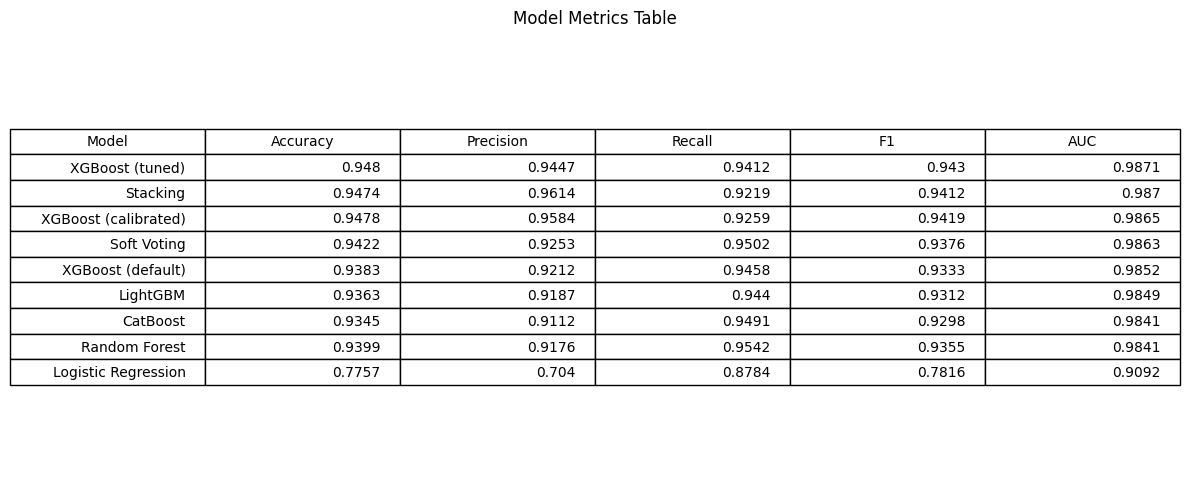

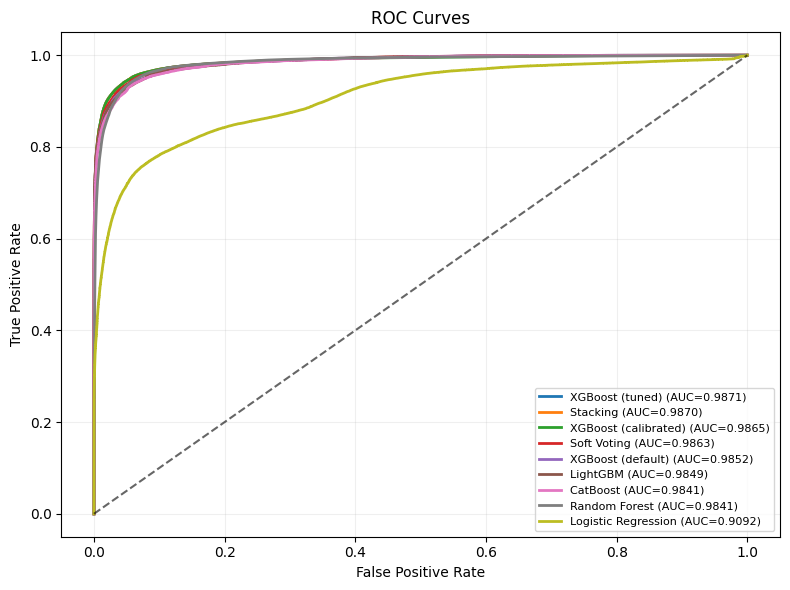

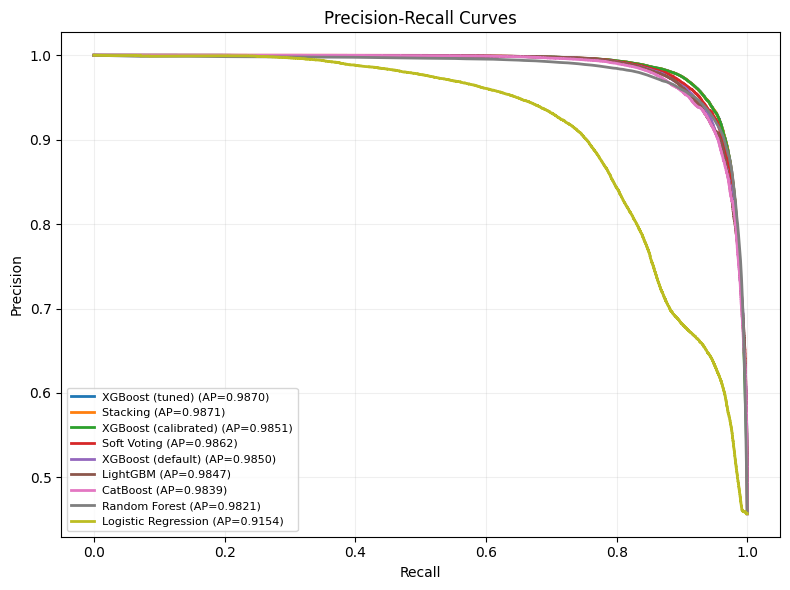

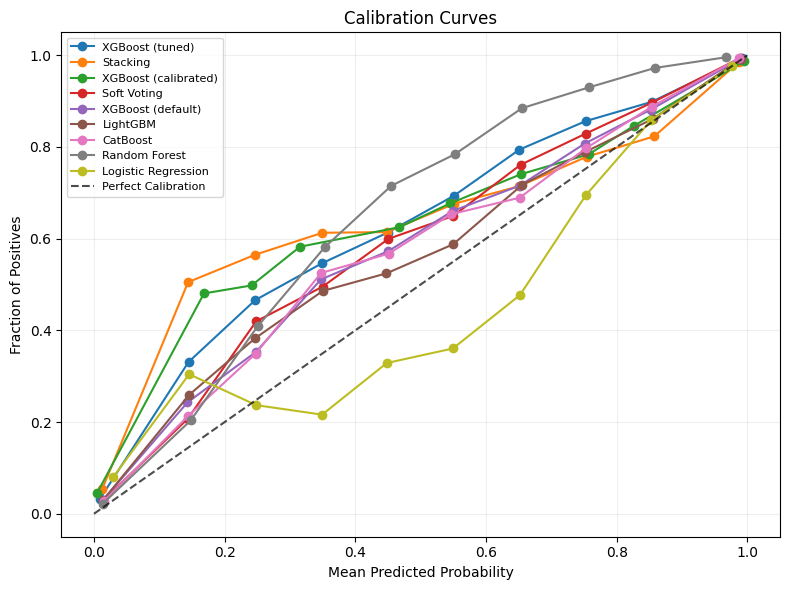

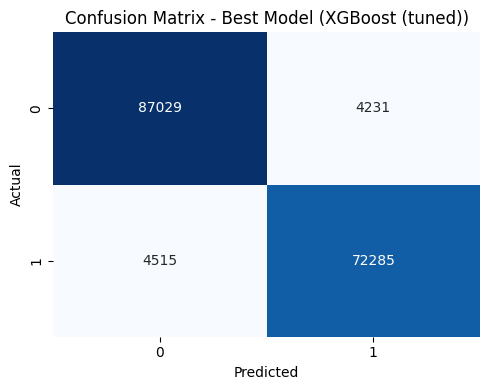

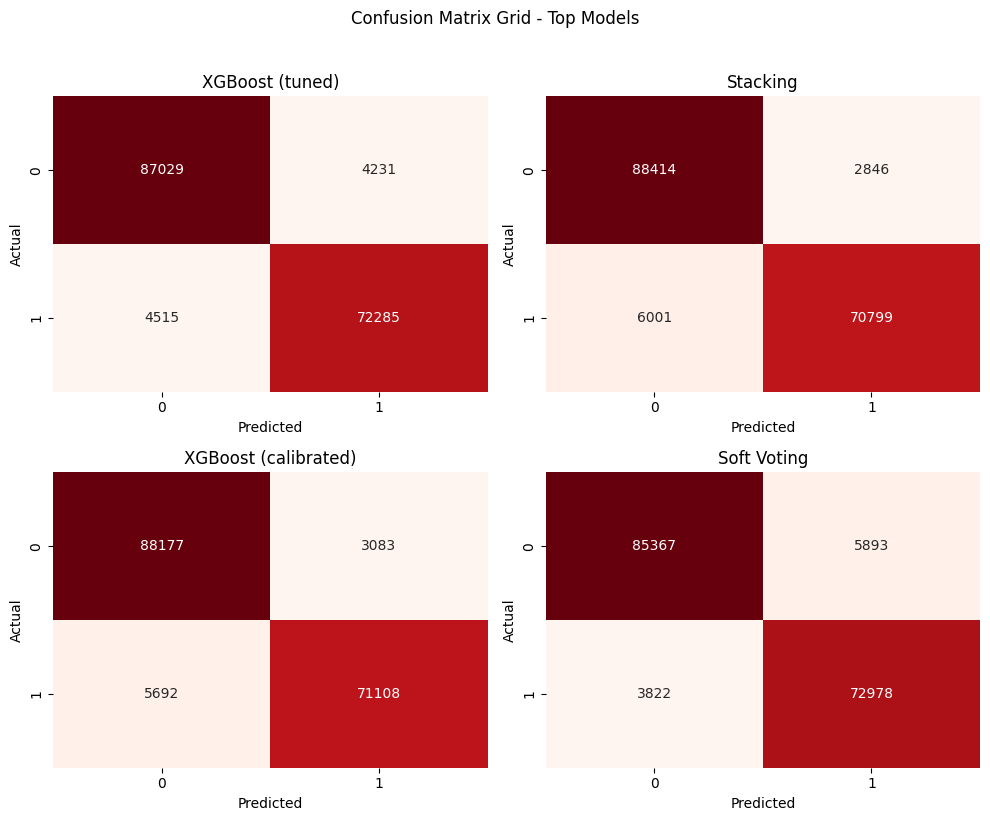

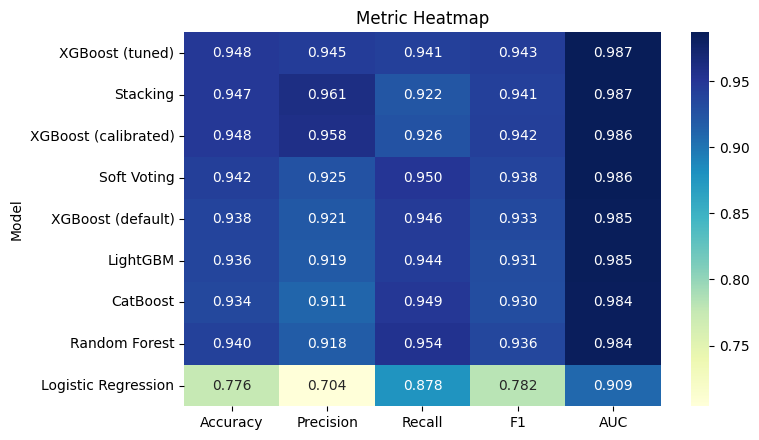

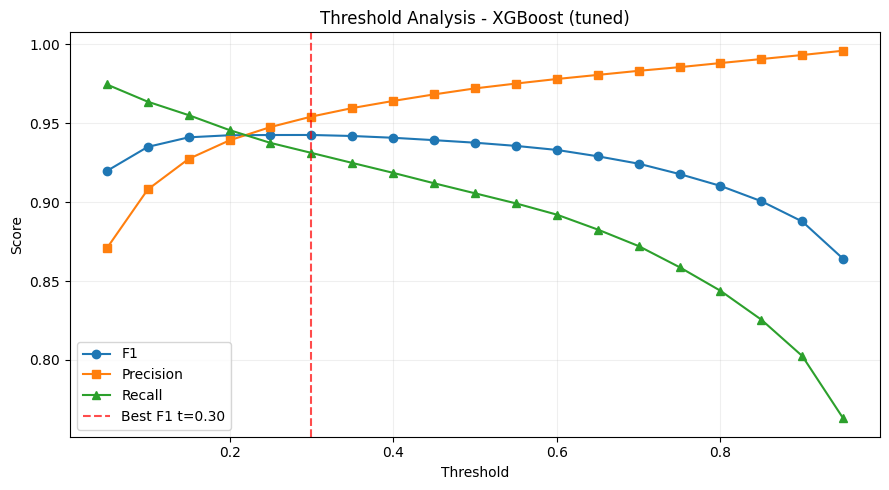

,triage,count,phish_rate,ratio
0,GECIR,68284,0.013927,0.406307
1,ENGELLE,66173,0.986807,0.393746
2,SUPHELI,33603,0.313930,0.199946


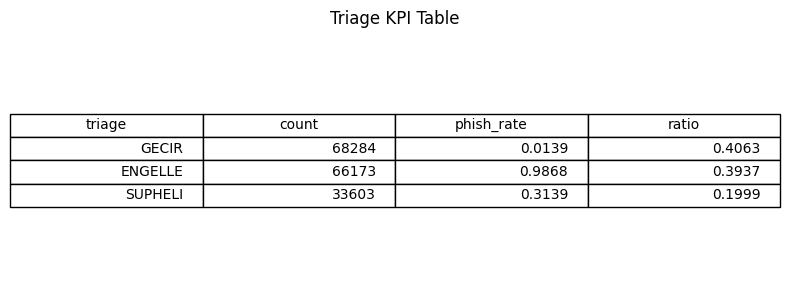

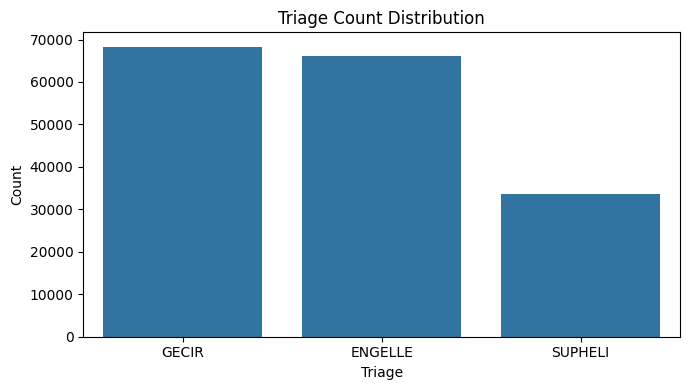

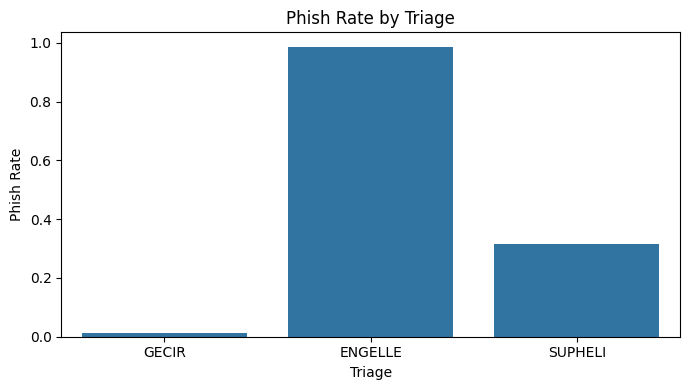

,LOW_THR,HIGH_THR,Best_Model
0,0.06,0.64,XGBoost (tuned)


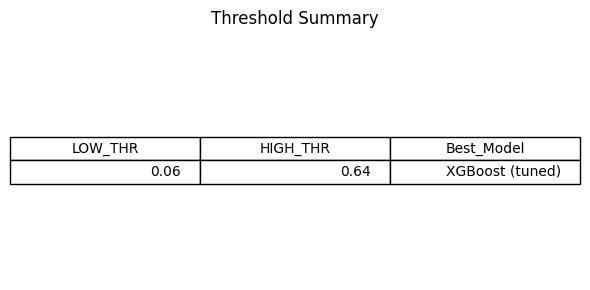

Tum gorsel ve tablolar kaydedildi.
Klasor: /content/tez_figures


In [30]:
# =========================================================
# TEZ GORSEL/TABLO PAKETI - DUZELTILMIS FULL SURUM
# Gerekli degiskenler: all_results, y_test
# Opsiyonel: triage_df, LOW_THR, HIGH_THR
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve

# ---------------------------------------------------------
# 0) cikti klasoru
# ---------------------------------------------------------
OUT_DIR = "/content/tez_figures"
os.makedirs(OUT_DIR, exist_ok=True)
print("Kayit klasoru:", OUT_DIR)

def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, name), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

def prepare_table_for_plot(df, decimals=4):
    """
    String+numeric karisik tablolari guvenli sekilde matplotlib table'a hazirlar.
    """
    tdf = df.copy()
    num_cols = tdf.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        tdf[num_cols] = tdf[num_cols].round(decimals)
    return tdf.astype(str)

def plot_table(df, title, filename, fig_width=12, row_height=0.55, font_size=10):
    tdf = prepare_table_for_plot(df, decimals=4)
    fig_h = max(3, row_height * len(tdf))
    fig, ax = plt.subplots(figsize=(fig_width, fig_h))
    ax.axis("off")
    tbl = ax.table(
        cellText=tdf.values,
        colLabels=tdf.columns,
        loc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(font_size)
    tbl.scale(1, 1.35)
    plt.title(title, pad=12)
    savefig(filename)

# ---------------------------------------------------------
# 1) Model metrik tablosu
# ---------------------------------------------------------
rows = []
for model_name, res in all_results.items():
    if "y_pred" in res and "y_proba" in res:
        rows.append({
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, res["y_pred"]),
            "Precision": precision_score(y_test, res["y_pred"], zero_division=0),
            "Recall": recall_score(y_test, res["y_pred"], zero_division=0),
            "F1": f1_score(y_test, res["y_pred"], zero_division=0),
            "AUC": roc_auc_score(y_test, res["y_proba"]),
        })

metrics_df = pd.DataFrame(rows).sort_values("AUC", ascending=False).reset_index(drop=True)
metrics_df.to_csv(os.path.join(OUT_DIR, "01_model_metrics.csv"), index=False)
display(metrics_df)

plot_table(
    df=metrics_df,
    title="Model Metrics Table",
    filename="01_model_metrics_table.png",
    fig_width=12
)

# ---------------------------------------------------------
# 2) ROC egirileri
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
for _, r in metrics_df.iterrows():
    name = r["Model"]
    y_proba = all_results[name]["y_proba"]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc(fpr, tpr):.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.2)
savefig("02_roc_curves.png")

# ---------------------------------------------------------
# 3) PR egirileri
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
for _, r in metrics_df.iterrows():
    name = r["Model"]
    y_proba = all_results[name]["y_proba"]
    p, rc, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(rc, p, lw=2, label=f"{name} (AP={ap:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend(loc="lower left", fontsize=8)
plt.grid(alpha=0.2)
savefig("03_pr_curves.png")

# ---------------------------------------------------------
# 4) Calibration curve
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
for _, r in metrics_df.iterrows():
    name = r["Model"]
    y_proba = all_results[name]["y_proba"]
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy="uniform")
    plt.plot(prob_pred, prob_true, marker="o", lw=1.5, label=name)
plt.plot([0, 1], [0, 1], "k--", alpha=0.7, label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curves")
plt.legend(loc="upper left", fontsize=8)
plt.grid(alpha=0.2)
savefig("04_calibration_curves.png")

# ---------------------------------------------------------
# 5) Confusion matrix - en iyi model
# ---------------------------------------------------------
best_model = metrics_df.iloc[0]["Model"]
best_pred = all_results[best_model]["y_pred"]
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion Matrix - Best Model ({best_model})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
savefig("05_confusion_best_model.png")

# ---------------------------------------------------------
# 6) Confusion matrix grid (ilk 4 model)
# ---------------------------------------------------------
top_k = min(4, len(metrics_df))
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i in range(4):
    ax = axes[i]
    if i < top_k:
        name = metrics_df.iloc[i]["Model"]
        y_pred = all_results[name]["y_pred"]
        cm_i = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm_i, annot=True, fmt="d", cmap="Reds", cbar=False, ax=ax)
        ax.set_title(name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    else:
        ax.axis("off")

plt.suptitle("Confusion Matrix Grid - Top Models", y=1.02)
savefig("06_confusion_grid_top4.png")

# ---------------------------------------------------------
# 7) Metrik heatmap
# ---------------------------------------------------------
heat_df = metrics_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "AUC"]]
plt.figure(figsize=(8, max(4, 0.5 * len(heat_df))))
sns.heatmap(heat_df, annot=True, fmt=".3f", cmap="YlGnBu", cbar=True)
plt.title("Metric Heatmap")
savefig("07_metric_heatmap.png")

# ---------------------------------------------------------
# 8) Threshold analizi (en iyi model)
# ---------------------------------------------------------
y_proba_best = all_results[best_model]["y_proba"]
thresholds = np.linspace(0.05, 0.95, 19)

f1s, precs, recs = [], [], []
for t in thresholds:
    pred_t = (y_proba_best >= t).astype(int)
    f1s.append(f1_score(y_test, pred_t))
    precs.append(precision_score(y_test, pred_t, zero_division=0))
    recs.append(recall_score(y_test, pred_t, zero_division=0))

best_t = thresholds[int(np.argmax(f1s))]

plt.figure(figsize=(9, 5))
plt.plot(thresholds, f1s, marker="o", label="F1")
plt.plot(thresholds, precs, marker="s", label="Precision")
plt.plot(thresholds, recs, marker="^", label="Recall")
plt.axvline(best_t, color="red", linestyle="--", alpha=0.7, label=f"Best F1 t={best_t:.2f}")
plt.title(f"Threshold Analysis - {best_model}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.2)
savefig("08_threshold_analysis_best_model.png")

# ---------------------------------------------------------
# 9) Triage raporu (varsa)
# ---------------------------------------------------------
if "triage_df" in globals():
    triage_counts = triage_df["triage"].value_counts().rename_axis("triage").reset_index(name="count")
    triage_rates = triage_df.groupby("triage")["y_true"].mean().rename("phish_rate").reset_index()

    triage_kpi = triage_counts.merge(triage_rates, on="triage", how="left")
    triage_kpi["ratio"] = triage_kpi["count"] / len(triage_df)
    triage_kpi = triage_kpi.sort_values("count", ascending=False).reset_index(drop=True)
    triage_kpi.to_csv(os.path.join(OUT_DIR, "09_triage_kpi.csv"), index=False)
    display(triage_kpi)

    plot_table(
        df=triage_kpi,
        title="Triage KPI Table",
        filename="09_triage_kpi_table.png",
        fig_width=8
    )

    plt.figure(figsize=(7, 4))
    sns.barplot(data=triage_kpi, x="triage", y="count")
    plt.title("Triage Count Distribution")
    plt.xlabel("Triage")
    plt.ylabel("Count")
    savefig("10_triage_count_distribution.png")

    plt.figure(figsize=(7, 4))
    sns.barplot(data=triage_kpi, x="triage", y="phish_rate")
    plt.title("Phish Rate by Triage")
    plt.xlabel("Triage")
    plt.ylabel("Phish Rate")
    savefig("11_triage_phish_rate.png")

    if "LOW_THR" in globals() and "HIGH_THR" in globals():
        summary = pd.DataFrame([{
            "LOW_THR": float(LOW_THR),
            "HIGH_THR": float(HIGH_THR),
            "Best_Model": best_model
        }])
        summary.to_csv(os.path.join(OUT_DIR, "12_threshold_summary.csv"), index=False)
        display(summary)
        plot_table(
            df=summary,
            title="Threshold Summary",
            filename="12_threshold_summary_table.png",
            fig_width=6
        )

print("Tum gorsel ve tablolar kaydedildi.")
print("Klasor:", OUT_DIR)